# Autonomous Intelligence as a Control Architecture
## A classroom simulator on a simplified Autódromo Hermanos Rodríguez

### Introduction

This notebook is designed to make one proposition visible rather than merely state it: **autonomous intelligence is not an LLM**. A self-driving vehicle is an especially useful teaching laboratory because successful autonomy requires several distinct forms of intelligence to cooperate under severe time, uncertainty, and safety constraints. The vehicle must observe an environment, transform imperfect observations into a usable representation of the world, decide what it wants to do, ensure that the intended action remains inside a safe operating envelope, translate intention into physical commands, observe what actually happened, and repeat the cycle continuously.

The architecture developed here is therefore organized around a closed loop:

**Environment → Perception → State Estimation → Judgment → Safety Governor → Execution → Vehicle → Feedback.**

The simulated car drives around a simplified representation of Mexico City's Autódromo Hermanos Rodríguez. The circuit is not intended to be a geometrically exact racing simulator. It is a controlled environment in which the architecture can be inspected. The track provides straights, curves, braking zones, boundaries, changing grip, obstacles, and disturbances. Those features create situations in which different components of intelligence become necessary.

The first layer is **perception**. Simulated sensors measure local track geometry, lateral displacement, heading error, velocity, nearby hazards, and environmental conditions. Measurements can be noisy or degraded. Perception does not decide what the vehicle should do; it creates observations.

The second layer is **state estimation**. Raw observations are transformed into a coherent internal representation: where the vehicle believes it is, how fast it is traveling, what curvature lies ahead, how much grip appears available, and how confident the system should be in those estimates. This distinction between observation and belief is fundamental to autonomous systems.

The third layer is **judgment**. Judgment itself has multiple time scales. A fast deterministic controller continuously determines target steering, throttle, and braking behavior. Above it, a slower supervisory reasoning layer uses Claude Haiku 4.5 to interpret unusual or strategically important situations. The LLM is therefore deliberately *not* placed in the millisecond actuator loop. It reasons about policy: whether the vehicle should become cautious, increase braking margins, reduce target speed, or alter its behavior because uncertainty has increased.

The fourth layer is the **safety governor**. This is one of the most important components of the notebook. An intelligent recommendation does not automatically acquire authority to act. The governor checks requested actions against deterministic constraints such as speed relative to curvature and grip, steering limits, track boundaries, collision margins, and confidence thresholds. It can accept, modify, or reject a recommendation. The architecture therefore separates intelligence from authority.

The fifth layer is **execution**. Approved intentions become steering, throttle, and brake commands. A simplified vehicle-dynamics model then determines the physical consequence. This creates another important distinction: a decision is not an outcome. Tires, inertia, grip, actuator saturation, and disturbances mediate between what the system requests and what the vehicle actually does.

Finally, **feedback** closes the loop. The new physical state becomes the next environment observed by the sensors. Intelligence is therefore represented not as a single answer but as a recurrent process of observation, belief formation, judgment, constrained action, and learning from consequences.

The notebook contains twenty-five executable code cells. Each is preceded by a substantial explanatory text cell. The early cells construct the world and vehicle. The middle cells create perception, state estimation, fast control, Claude supervision, governance, and execution. The final cells integrate the system, visualize the live signal flow, inject disturbances such as rain and sensor degradation, and compare alternative architectures.

The principal visualization intentionally gives the architecture equal or greater prominence than the moving car. During simulation, students can inspect the data moving between layers: sensor measurements, estimated state, strategic mode, LLM recommendation, governor verdict, actuator commands, and resulting vehicle response. The objective is to reveal the invisible machinery beneath the apparently simple statement that “the car drives itself.”

The simulator is pedagogical rather than safety-certified and must not be used to control a real vehicle. Its value lies precisely in making abstractions inspectable. By the end, the student should be able to explain why autonomous systems combine statistical estimation, geometry, optimization, feedback control, generative reasoning, deterministic rules, physical execution, and governance—and why replacing this architecture with a single language model would be both technically inadequate and conceptually misleading.

### Cell 1 — Install and import the simulation stack

This cell develops one layer of the simulator while preserving the separation of responsibilities that is essential to the control architecture. The purpose is not simply to add another Python function. It is to make explicit **what information this component is allowed to see, what transformation it performs, and what authority it possesses**. Those boundaries are important because autonomous systems fail when perception, reasoning, control, and execution are casually collapsed into a single opaque mechanism.

At this stage, pay attention to the direction of information flow. A component should consume a defined input and produce a defined output that can be inspected by the next component. Later, the live dashboard will expose these messages while the vehicle moves. This allows the class to distinguish a sensor observation from an estimated state, an estimated state from a judgment, a judgment from an authorized command, and an authorized command from the physical response of the vehicle.

The code deliberately favors clarity and inspectability over high-fidelity motorsport physics. We are building a pedagogical simulator, not a safety-certified autonomous-driving stack or a Formula 1 engineering model. Nevertheless, the conceptual separation mirrors real control-system ideas: noisy measurements, state representation, reference trajectories, feedback control, supervisory reasoning, constraints, actuator saturation, physical dynamics, and repeated feedback.

A second theme is **time scale**. Not every form of intelligence should operate at the same frequency. Geometry and deterministic feedback can be evaluated every simulation step. Strategic LLM reasoning is slower and should be invoked only at supervisory intervals or when an event warrants reconsideration. The simulator therefore rejects the tempting but unrealistic architecture in which a language model is asked to generate steering commands continuously.

As you run this cell, interpret its output as one message in a larger institutional architecture. The same conceptual structure can later be translated to finance: observations become data, state estimation becomes analytical interpretation, judgment becomes policy or recommendation, governance becomes limits and approvals, execution becomes transactions, and feedback becomes monitoring of realized consequences.

In [ ]:
# @title
# Cell 1 — install/import
!pip -q install anthropic

import math, json, random, time, os
from dataclasses import dataclass, asdict
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

try:
    from google.colab import userdata
except Exception:
    userdata = None

try:
    import anthropic
except Exception:
    anthropic = None

print("Simulation stack ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 50.9 MB/s eta 0:00:00
Simulation stack ready.


### Cell 2 — Define configuration and reproducibility

This cell develops one layer of the simulator while preserving the separation of responsibilities that is essential to the control architecture. The purpose is not simply to add another Python function. It is to make explicit **what information this component is allowed to see, what transformation it performs, and what authority it possesses**. Those boundaries are important because autonomous systems fail when perception, reasoning, control, and execution are casually collapsed into a single opaque mechanism.

At this stage, pay attention to the direction of information flow. A component should consume a defined input and produce a defined output that can be inspected by the next component. Later, the live dashboard will expose these messages while the vehicle moves. This allows the class to distinguish a sensor observation from an estimated state, an estimated state from a judgment, a judgment from an authorized command, and an authorized command from the physical response of the vehicle.

The code deliberately favors clarity and inspectability over high-fidelity motorsport physics. We are building a pedagogical simulator, not a safety-certified autonomous-driving stack or a Formula 1 engineering model. Nevertheless, the conceptual separation mirrors real control-system ideas: noisy measurements, state representation, reference trajectories, feedback control, supervisory reasoning, constraints, actuator saturation, physical dynamics, and repeated feedback.

A second theme is **time scale**. Not every form of intelligence should operate at the same frequency. Geometry and deterministic feedback can be evaluated every simulation step. Strategic LLM reasoning is slower and should be invoked only at supervisory intervals or when an event warrants reconsideration. The simulator therefore rejects the tempting but unrealistic architecture in which a language model is asked to generate steering commands continuously.

As you run this cell, interpret its output as one message in a larger institutional architecture. The same conceptual structure can later be translated to finance: observations become data, state estimation becomes analytical interpretation, judgment becomes policy or recommendation, governance becomes limits and approvals, execution becomes transactions, and feedback becomes monitoring of realized consequences.

In [ ]:
# @title
# Cell 2 — configuration
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DT = 0.10
WHEELBASE = 2.8
MAX_STEER = np.deg2rad(28)
MAX_ACCEL = 6.0
MAX_BRAKE = 12.0
BASE_GRIP = 1.0
LLM_INTERVAL_STEPS = 80

CONFIG = dict(dt=DT, wheelbase=WHEELBASE, max_steer_deg=28,
              max_accel=MAX_ACCEL, max_brake=MAX_BRAKE,
              base_grip=BASE_GRIP, llm_interval_steps=LLM_INTERVAL_STEPS)
CONFIG


{'dt': 0.1,
 'wheelbase': 2.8,
 'max_steer_deg': 28,
 'max_accel': 6.0,
 'max_brake': 12.0,
 'base_grip': 1.0,
 'llm_interval_steps': 80}

### Decoding Cell 2 (Vehicle & Track Configuration) in Car Terms

If you have a background in cars, racing, or track days, this cell is simply defining your **car's spec sheet, the track surface, and your telemetry/ECU update rate**:

*   **`DT = 0.10` (ECU/Telemetry Refresh Rate):** This is your controller's sampling frequency. It means the car's computers read sensor data and adjust steering or throttle once every **0.10 seconds (10 Hz)**.
*   **`WHEELBASE = 2.8` (Chassis Geometry):** The distance from the center of the front wheels to the center of the rear wheels is **2.8 meters** (roughly 110 inches). This is very close to a modern Formula 1 car or a sport sedan like a BMW 3-Series. A longer wheelbase provides high-speed stability, while a shorter one turns in faster.
*   **`MAX_STEER = np.deg2rad(28)` (Steering Lock):** This is the mechanical limit of your steering rack. The front wheels can only turn a maximum of **28 degrees** left or right from center.
*   **`MAX_ACCEL = 6.0` (Power/Weight & Longitudinal Grip Limit):** Under full throttle, the maximum forward acceleration is capped at **6.0 m/s²** (roughly **0.61g**). Think of this as the maximum power the engine can put down to the tires before traction control would have to step in.
*   **`MAX_BRAKE = 12.0` (Braking Performance):** The maximum stopping power is **12.0 m/s²** (about **1.22g**). In performance driving, brakes are always stronger than the engine, allowing you to shed speed twice as fast as you can build it.
*   **`BASE_GRIP = 1.0` (Tire Compound & Track Surface):** This is your baseline **coefficient of friction ($̲̲$)**. A value of `1.0` represents warm racing slick tires on a clean, dry tarmac. If it rains, this value drops, meaning the tires will break traction much easier.
*   **`LLM_INTERVAL_STEPS = 80` (The Crew Chief's Interval):** Because the Large Language Model (the AI supervisor) takes longer to "think," it doesn't do micro-steering adjustments. Instead, it acts like a **Crew Chief on the pit wall**, checking in every **80 simulation steps (every 8 seconds)** to adjust the strategy (e.g., telling the driver to back off because of rain).

### Cell 3 — Build the simplified circuit geometry

This cell develops one layer of the simulator while preserving the separation of responsibilities that is essential to the control architecture. The purpose is not simply to add another Python function. It is to make explicit **what information this component is allowed to see, what transformation it performs, and what authority it possesses**. Those boundaries are important because autonomous systems fail when perception, reasoning, control, and execution are casually collapsed into a single opaque mechanism.

At this stage, pay attention to the direction of information flow. A component should consume a defined input and produce a defined output that can be inspected by the next component. Later, the live dashboard will expose these messages while the vehicle moves. This allows the class to distinguish a sensor observation from an estimated state, an estimated state from a judgment, a judgment from an authorized command, and an authorized command from the physical response of the vehicle.

The code deliberately favors clarity and inspectability over high-fidelity motorsport physics. We are building a pedagogical simulator, not a safety-certified autonomous-driving stack or a Formula 1 engineering model. Nevertheless, the conceptual separation mirrors real control-system ideas: noisy measurements, state representation, reference trajectories, feedback control, supervisory reasoning, constraints, actuator saturation, physical dynamics, and repeated feedback.

A second theme is **time scale**. Not every form of intelligence should operate at the same frequency. Geometry and deterministic feedback can be evaluated every simulation step. Strategic LLM reasoning is slower and should be invoked only at supervisory intervals or when an event warrants reconsideration. The simulator therefore rejects the tempting but unrealistic architecture in which a language model is asked to generate steering commands continuously.

As you run this cell, interpret its output as one message in a larger institutional architecture. The same conceptual structure can later be translated to finance: observations become data, state estimation becomes analytical interpretation, judgment becomes policy or recommendation, governance becomes limits and approvals, execution becomes transactions, and feedback becomes monitoring of realized consequences.

### Decoding Cell 3 (Track Geometry / Layout Generator) in Car Terms

If you understand cars, track days, or track layouts, **Cell 3** is the code that **designs and builds your racetrack** (a simplified, mathematical model inspired by the *Autódromo Hermanos Rodríguez* in Mexico City):

*   **`theta = np.linspace(0, 2*np.pi, 900)` (Survey Points):** This divides a full circle ($360^\circ$) into **900 coordinate points**. These act as the survey points mapped out by GPS to construct the track layout.
*   **`r = 1.0 + 0.16*np.sin(3*theta) + 0.08*np.sin(7*theta + 0.5)` (The Elevation / Radius Blueprint):** A perfect circle is a boring track. This formula injects wave functions (sine waves) to distort the circle, adding realistic "flow"—creating fast sweeping bends, complex sequences, and tighter corners.
*   **`x_track` & `y_track` (Scaling to Real-World Dimensions):** These lines stretch the coordinates into a realistic layout. By scaling the $x$ values by up to `520` meters and $y$ values by `300` meters, it shapes the track into a classic **elongated grand-prix circuit geometry** (about 1.2 km wide and 0.6 km tall) with a long straightaway and tight infield complexes.
*   **`track = np.vstack([track, track[0]])` (Closing the Circuit):** This connects the final coordinate back to the very first point on the grid. In racing terms, this ensures a **fully closed loop** with a start/finish line so the car can complete continuous laps.
*   **`plt.plot(track[:,0], track[:,1])` (The Track Map):** This plots your track map on the screen so you can inspect the straights, turns, and apexes before the car hits the pavement.

### Cell 4 — Create the track reference frame

This cell develops one layer of the simulator while preserving the separation of responsibilities that is essential to the control architecture. The purpose is not simply to add another Python function. It is to make explicit **what information this component is allowed to see, what transformation it performs, and what authority it possesses**. Those boundaries are important because autonomous systems fail when perception, reasoning, control, and execution are casually collapsed into a single opaque mechanism.

At this stage, pay attention to the direction of information flow. A component should consume a defined input and produce a defined output that can be inspected by the next component. Later, the live dashboard will expose these messages while the vehicle moves. This allows the class to distinguish a sensor observation from an estimated state, an estimated state from a judgment, a judgment from an authorized command, and an authorized command from the physical response of the vehicle.

The code deliberately favors clarity and inspectability over high-fidelity motorsport physics. We are building a pedagogical simulator, not a safety-certified autonomous-driving stack or a Formula 1 engineering model. Nevertheless, the conceptual separation mirrors real control-system ideas: noisy measurements, state representation, reference trajectories, feedback control, supervisory reasoning, constraints, actuator saturation, physical dynamics, and repeated feedback.

A second theme is **time scale**. Not every form of intelligence should operate at the same frequency. Geometry and deterministic feedback can be evaluated every simulation step. Strategic LLM reasoning is slower and should be invoked only at supervisory intervals or when an event warrants reconsideration. The simulator therefore rejects the tempting but unrealistic architecture in which a language model is asked to generate steering commands continuously.

As you run this cell, interpret its output as one message in a larger institutional architecture. The same conceptual structure can later be translated to finance: observations become data, state estimation becomes analytical interpretation, judgment becomes policy or recommendation, governance becomes limits and approvals, execution becomes transactions, and feedback becomes monitoring of realized consequences.

In [ ]:
# Cell 4 — reference frame
dxy = np.diff(track, axis=0)
seg_len = np.linalg.norm(dxy, axis=1)
s = np.concatenate([[0], np.cumsum(seg_len)])
heading = np.arctan2(dxy[:,1], dxy[:,0])
heading = np.append(heading, heading[-1])
curvature = np.gradient(np.unwrap(heading), s, edge_order=1)
TRACK_LENGTH = s[-1]

def nearest_track_index(x, y):
    d2 = (track[:,0]-x)**2 + (track[:,1]-y)**2
    return int(np.argmin(d2))

print(f"Reference lap length: {TRACK_LENGTH/1000:.2f} km")


Reference lap length: 3.00 km


### Decoding Cell 4 (Track Reference Frame) in Car Terms

If you understand performance driving, data logging, or racetrack mapping, **Cell 4** is the code that **scouts the track and programs your dashboard telemetry**:

*   **`dxy = np.diff(track, axis=0)` (Micro-sectors):** This breaks the entire circuit down into tiny segments between the coordinate points. Think of it as dividing the 3 km track into thousands of tiny "micro-sectors."
*   **`seg_len = np.linalg.norm(dxy, axis=1)` (Segment Distance):** This calculates the exact distance of each tiny micro-sector in meters.
*   **`s = ...` (The Odometer / Lap Distance):** This accumulates all those segment lengths to create a continuous track coordinate. It's like your trip odometer, letting the car know exactly how many meters it has traveled from the start/finish line (from 0 to 3000 meters).
*   **`heading = np.arctan2(...)` (Vehicle Yaw / Target Angle):** This defines which way the track is pointing at every single coordinate. If you were drawing a racing line, this represents the angle your car needs to be pointed at to stay perfectly parallel with the track center.
*   **`curvature = np.gradient(...)` (Steering Effort / Corner Sharpness):** This is the most critical calculation. It measures how fast the track heading changes per meter.
    *   A straightaway has **zero curvature** (no steering effort needed).
    *   A tight hairpin has **high curvature** (requires slow entry speeds and maximum steering lock).
    *   This is the telemetry data the ECU uses to know a braking zone or turn is approaching.
*   **`TRACK_LENGTH` (Track Distance):** The total distance of one lap, calculated here as **3.00 kilometers** (approx. 1.86 miles).
*   **`def nearest_track_index(x, y)` (GPS Position Locator):** This acts like a high-frequency **GPS transponder**. It takes the car's current coordinates ($x, y$) and instantly maps it to the closest coordinate point on the racetrack map so the onboard systems know exactly where the car is on the lap.

### Cell 5 — Define the vehicle state and physical limits

This cell develops one layer of the simulator while preserving the separation of responsibilities that is essential to the control architecture. The purpose is not simply to add another Python function. It is to make explicit **what information this component is allowed to see, what transformation it performs, and what authority it possesses**. Those boundaries are important because autonomous systems fail when perception, reasoning, control, and execution are casually collapsed into a single opaque mechanism.

At this stage, pay attention to the direction of information flow. A component should consume a defined input and produce a defined output that can be inspected by the next component. Later, the live dashboard will expose these messages while the vehicle moves. This allows the class to distinguish a sensor observation from an estimated state, an estimated state from a judgment, a judgment from an authorized command, and an authorized command from the physical response of the vehicle.

The code deliberately favors clarity and inspectability over high-fidelity motorsport physics. We are building a pedagogical simulator, not a safety-certified autonomous-driving stack or a Formula 1 engineering model. Nevertheless, the conceptual separation mirrors real control-system ideas: noisy measurements, state representation, reference trajectories, feedback control, supervisory reasoning, constraints, actuator saturation, physical dynamics, and repeated feedback.

A second theme is **time scale**. Not every form of intelligence should operate at the same frequency. Geometry and deterministic feedback can be evaluated every simulation step. Strategic LLM reasoning is slower and should be invoked only at supervisory intervals or when an event warrants reconsideration. The simulator therefore rejects the tempting but unrealistic architecture in which a language model is asked to generate steering commands continuously.

As you run this cell, interpret its output as one message in a larger institutional architecture. The same conceptual structure can later be translated to finance: observations become data, state estimation becomes analytical interpretation, judgment becomes policy or recommendation, governance becomes limits and approvals, execution becomes transactions, and feedback becomes monitoring of realized consequences.

In [ ]:
# Cell 5 — vehicle state
@dataclass
class VehicleState:
    x: float
    y: float
    yaw: float
    speed: float
    steer: float = 0.0
    throttle: float = 0.0
    brake: float = 0.0
    grip: float = 1.0
    lap: int = 0
    step: int = 0

i0 = 0
car = VehicleState(track[i0,0], track[i0,1], heading[i0], 25.0)
asdict(car)


{'x': np.float64(629.9441024059348),
 'y': np.float64(0.0),
 'yaw': np.float64(0.5614529212858254),
 'speed': 25.0,
 'steer': 0.0,
 'throttle': 0.0,
 'brake': 0.0,
 'grip': 1.0,
 'lap': 0,
 'step': 0}

### Decoding Cell 5 (Vehicle State) in Car Terms

If you understand cars, **Cell 5** defines the **real-time telemetry and dashboard readings** of your vehicle at any given instant during a run:

*   **`x` and `y` (GPS Position):** These are the exact coordinate points of your car on the track. Think of it like your GPS transponder tracking your vehicle's physical location on the circuit.
*   **`yaw` (Vehicle Heading):** This is the direction your car's nose is pointing relative to a fixed direction, measured in radians. In racing data analysis, this is your vehicle's heading angle.
*   **`speed` (Speedometer):** The forward speed of your vehicle in meters per second (mps). To convert to km/h, the dashboard multiplies this value by 3.6.
*   **`steer` (Steering Angle / Rack Position):** This is the current physical angle of your front wheels relative to dead-center. A value of `0.0` means the front wheels are pointing straight ahead; positive/negative values mean you are turning the steering wheel.
*   **`throttle` (Gas Pedal):** This represents pedal travel from `0.0` (off throttle) to `1.0` (100% wide-open throttle).
*   **`brake` (Brake Pedal):** This represents pressure on the brake pedal from `0.0` (off brakes) to `1.0` (100% full threshold braking).
*   **`grip` (Tire Traction / Friction Limit):** This is the physical grip multiplier available at the contact patch. If your tires are warm and the track is dry, it's at `1.0`. If you hit standing water or ice, this drops instantly, telling you the tires have much less traction to work with.
*   **`lap` and `step` (Lap Counter & Telemetry Timer):** `lap` counts your completed laps, and `step` is like the high-speed clock on your data logger, ticking up every 0.1 seconds to mark a new line of telemetry data.

### Cell 6 — Implement simplified vehicle dynamics

This cell develops one layer of the simulator while preserving the separation of responsibilities that is essential to the control architecture. The purpose is not simply to add another Python function. It is to make explicit **what information this component is allowed to see, what transformation it performs, and what authority it possesses**. Those boundaries are important because autonomous systems fail when perception, reasoning, control, and execution are casually collapsed into a single opaque mechanism.

At this stage, pay attention to the direction of information flow. A component should consume a defined input and produce a defined output that can be inspected by the next component. Later, the live dashboard will expose these messages while the vehicle moves. This allows the class to distinguish a sensor observation from an estimated state, an estimated state from a judgment, a judgment from an authorized command, and an authorized command from the physical response of the vehicle.

The code deliberately favors clarity and inspectability over high-fidelity motorsport physics. We are building a pedagogical simulator, not a safety-certified autonomous-driving stack or a Formula 1 engineering model. Nevertheless, the conceptual separation mirrors real control-system ideas: noisy measurements, state representation, reference trajectories, feedback control, supervisory reasoning, constraints, actuator saturation, physical dynamics, and repeated feedback.

A second theme is **time scale**. Not every form of intelligence should operate at the same frequency. Geometry and deterministic feedback can be evaluated every simulation step. Strategic LLM reasoning is slower and should be invoked only at supervisory intervals or when an event warrants reconsideration. The simulator therefore rejects the tempting but unrealistic architecture in which a language model is asked to generate steering commands continuously.

As you run this cell, interpret its output as one message in a larger institutional architecture. The same conceptual structure can later be translated to finance: observations become data, state estimation becomes analytical interpretation, judgment becomes policy or recommendation, governance becomes limits and approvals, execution becomes transactions, and feedback becomes monitoring of realized consequences.

In [ ]:
# Cell 6 — dynamics
def vehicle_step(st, steer_cmd, throttle_cmd, brake_cmd, dt=DT):
    steer = float(np.clip(steer_cmd, -MAX_STEER, MAX_STEER))
    throttle = float(np.clip(throttle_cmd, 0, 1))
    brake = float(np.clip(brake_cmd, 0, 1))
    accel = throttle*MAX_ACCEL - brake*MAX_BRAKE*st.grip - 0.0025*st.speed**2
    speed = max(0.0, st.speed + accel*dt)
    yaw_rate = speed / WHEELBASE * math.tan(steer) * min(1.0, st.grip)
    yaw = st.yaw + yaw_rate*dt
    x = st.x + speed*math.cos(yaw)*dt
    y = st.y + speed*math.sin(yaw)*dt
    return VehicleState(x,y,yaw,speed,steer,throttle,brake,st.grip,st.lap,st.step+1)

print("Bicycle-model dynamics defined.")


Bicycle-model dynamics defined.


### Decoding Cell 6 (Vehicle Dynamics) in Car Terms

If you understand cars, **Cell 6** is the mechanical **physics engine** of the simulator. It models how your inputs (steering, gas, brakes) translate to tire grip and vehicle motion using a simplified **"Bicycle Model"**:

*   **Actuator Saturation (`np.clip`):** This represents the mechanical limits of your hardware. Your driver can try to turn the wheel 45 degrees or stomp the brake pedal past 100%, but the physical steering rack stops at **28 degrees** (`MAX_STEER`) and the pedals bottom out at **1.0 (100% capacity)**.
*   **`accel = throttle*MAX_ACCEL - brake*MAX_BRAKE*st.grip - 0.0025*st.speed**2` (The Force Balance):** This is Newton's second law ($F=ma$) simplified for a car:
    *   `throttle * MAX_ACCEL` is your engine's power driving you forward.
    *   `brake * MAX_BRAKE * st.grip` is your stopping force. Notice that braking is directly multiplied by `st.grip`. If you are on ice (low grip), slamming the brakes won't slow you down as quickly because the ABS/tires will slide.
    *   `- 0.0025 * st.speed**2` is **Aerodynamic Drag** (aerodynamic drag increases with the square of speed). The faster the car goes, the more wind resistance fights the engine.
*   **`yaw_rate = speed / WHEELBASE * math.tan(steer) * min(1.0, st.grip)` (The Steering Physics / Slip):** This determines how fast the car's nose rotates (yaw rate):
    *   `speed / WHEELBASE * math.tan(steer)` is the classic geometric turning equation for a rigid vehicle.
    *   `* min(1.0, st.grip)` acts as a basic **slip/understeer model**. If your tires lose grip (e.g., on a wet track), the front wheels lose bite, and the car pushes (understeers), rotating less than the mechanical steering angle would normally dictate.

### Cell 7 — Create the simulated sensor suite

This cell develops one layer of the simulator while preserving the separation of responsibilities that is essential to the control architecture. The purpose is not simply to add another Python function. It is to make explicit **what information this component is allowed to see, what transformation it performs, and what authority it possesses**. Those boundaries are important because autonomous systems fail when perception, reasoning, control, and execution are casually collapsed into a single opaque mechanism.

At this stage, pay attention to the direction of information flow. A component should consume a defined input and produce a defined output that can be inspected by the next component. Later, the live dashboard will expose these messages while the vehicle moves. This allows the class to distinguish a sensor observation from an estimated state, an estimated state from a judgment, a judgment from an authorized command, and an authorized command from the physical response of the vehicle.

The code deliberately favors clarity and inspectability over high-fidelity motorsport physics. We are building a pedagogical simulator, not a safety-certified autonomous-driving stack or a Formula 1 engineering model. Nevertheless, the conceptual separation mirrors real control-system ideas: noisy measurements, state representation, reference trajectories, feedback control, supervisory reasoning, constraints, actuator saturation, physical dynamics, and repeated feedback.

A second theme is **time scale**. Not every form of intelligence should operate at the same frequency. Geometry and deterministic feedback can be evaluated every simulation step. Strategic LLM reasoning is slower and should be invoked only at supervisory intervals or when an event warrants reconsideration. The simulator therefore rejects the tempting but unrealistic architecture in which a language model is asked to generate steering commands continuously.

As you run this cell, interpret its output as one message in a larger institutional architecture. The same conceptual structure can later be translated to finance: observations become data, state estimation becomes analytical interpretation, judgment becomes policy or recommendation, governance becomes limits and approvals, execution becomes transactions, and feedback becomes monitoring of realized consequences.

In [ ]:
# Cell 7 — sensors
def ideal_sensors(st):
    idx = nearest_track_index(st.x, st.y)
    ref = track[idx]
    lateral_error = float(np.linalg.norm(np.array([st.x,st.y])-ref))
    h_err = math.atan2(math.sin(st.yaw-heading[idx]), math.cos(st.yaw-heading[idx]))
    ahead = min(idx+25, len(curvature)-1)
    return {
        "track_index": idx, "speed": st.speed, "yaw": st.yaw,
        "lateral_error": lateral_error, "heading_error": h_err,
        "curvature_now": float(curvature[idx]),
        "curvature_ahead": float(np.max(np.abs(curvature[idx:ahead+1]))),
        "grip_true": st.grip
    }

ideal_sensors(car)


{'track_index': 0,
 'speed': 25.0,
 'yaw': np.float64(0.5614529212858254),
 'lateral_error': 0.0,
 'heading_error': 0.0,
 'curvature_now': 0.0045139069659833565,
 'curvature_ahead': 0.025798147094198975,
 'grip_true': 1.0}

### Decoding Cell 7 (Simulated Sensors) in Car Terms

If you understand cars, **Cell 7** represents your vehicle's onboard **telemetry sensor package** (like a Motec data logger or VBOX GPS unit) reading perfect, error-free physical values:

*   **`track_index` (GPS Track Position):** This acts like a track-map matcher. It uses your GPS coordinates to determine exactly which micro-sector of the track you are currently in.
*   **`speed` (Wheel Speed Sensors / GPS Speed):** Your actual, true vehicle speed in meters per second (mps).
*   **`yaw` (Compass / Gyroscope):** The true compass heading of the car's nose.
*   **`lateral_error` (Distance to Racing Line):** This measures how far the car has drifted off-center from the track's middle reference line (the perfect racing line) in meters. If this is `0.0`, you are perfectly dead-center.
*   **`heading_error` (Slip / Steering Deviation):** The angle difference between where your car's nose is pointing (`yaw`) and where the track curves. If this is `0.0`, your car is pointing perfectly parallel to the direction of the road.
*   **`curvature_now` (Local Corner Sharpness):** The instant curvature of the road directly under your tires.
*   **`curvature_ahead` (Corner Spotting / Looking Ahead):** This is the equivalent of a skilled driver **looking 25 steps ahead** through the windshield to spot an upcoming corner. It scans the track ahead to see the highest curvature (sharpest bend) coming up so the system can plan when to get on the brakes.
*   **`grip_true` (Real-time Traction Coefficient):** The actual mechanical grip available at the tire contact patches.

### Cell 8 — Add sensor noise, latency, and confidence

This cell develops one layer of the simulator while preserving the separation of responsibilities that is essential to the control architecture. The purpose is not simply to add another Python function. It is to make explicit **what information this component is allowed to see, what transformation it performs, and what authority it possesses**. Those boundaries are important because autonomous systems fail when perception, reasoning, control, and execution are casually collapsed into a single opaque mechanism.

At this stage, pay attention to the direction of information flow. A component should consume a defined input and produce a defined output that can be inspected by the next component. Later, the live dashboard will expose these messages while the vehicle moves. This allows the class to distinguish a sensor observation from an estimated state, an estimated state from a judgment, a judgment from an authorized command, and an authorized command from the physical response of the vehicle.

The code deliberately favors clarity and inspectability over high-fidelity motorsport physics. We are building a pedagogical simulator, not a safety-certified autonomous-driving stack or a Formula 1 engineering model. Nevertheless, the conceptual separation mirrors real control-system ideas: noisy measurements, state representation, reference trajectories, feedback control, supervisory reasoning, constraints, actuator saturation, physical dynamics, and repeated feedback.

A second theme is **time scale**. Not every form of intelligence should operate at the same frequency. Geometry and deterministic feedback can be evaluated every simulation step. Strategic LLM reasoning is slower and should be invoked only at supervisory intervals or when an event warrants reconsideration. The simulator therefore rejects the tempting but unrealistic architecture in which a language model is asked to generate steering commands continuously.

As you run this cell, interpret its output as one message in a larger institutional architecture. The same conceptual structure can later be translated to finance: observations become data, state estimation becomes analytical interpretation, judgment becomes policy or recommendation, governance becomes limits and approvals, execution becomes transactions, and feedback becomes monitoring of realized consequences.

In [ ]:
# Cell 8 — noise/confidence
SENSOR_HEALTH = 1.0

def noisy_sensors(st, health=None):
    health = SENSOR_HEALTH if health is None else health
    z = ideal_sensors(st)
    sigma = (1.0-health)
    z["speed_measured"] = max(0, z["speed"] + np.random.normal(0, 2.0*sigma))
    z["heading_measured"] = z["yaw"] + np.random.normal(0, 0.05*sigma)
    z["lateral_measured"] = z["lateral_error"] + np.random.normal(0, 1.5*sigma)
    z["confidence"] = float(np.clip(0.25 + 0.75*health, 0, 1))
    return z

noisy_sensors(car, 0.85)


{'track_index': 0,
 'speed': 25.0,
 'yaw': np.float64(0.5614529212858254),
 'lateral_error': 0.0,
 'heading_error': 0.0,
 'curvature_now': 0.0045139069659833565,
 'curvature_ahead': 0.025798147094198975,
 'grip_true': 1.0,
 'speed_measured': 25.14901424590337,
 'heading_measured': np.float64(0.5604159390270415),
 'lateral_measured': 0.14572992107265584,
 'confidence': 0.8875}

### Decoding Cell 8 (Sensor Noise & Confidence Diagnostics) in Car Terms

If you understand cars, **Cell 8** is the simulator's way of introducing **poor sensor grounds, electrical interference, or bad weather disrupting your telemetry sensors**:

*   **`SENSOR_HEALTH` (Sensor Integrity):** Think of this as the physical health of your sensors, wiring harness, and connectors. A value of `1.0` means everything is clean, securely plugged in, and grounded. A lower value (e.g., `0.42`) simulates bad wiring, direct interference, or mud/grime blocking a camera lens.
*   **`np.random.normal(0, 2.0*sigma)` (Signal Noise):** When sensor health drops, this line injects random static ("fuzz") into the readings.
    *   **Speedometer:** Instead of reading a steady 100 km/h, a noisy sensor will jump erratically between 95 and 105 km/h.
    *   **Compass/Yaw:** The steering controller will think the car's heading is fluctuating, simulating a steering angle sensor or compass getting confused by vibration.
    *   **Lateral Error:** The GPS reading of your position relative to the center of the track gets jittery, as if the car is shaking off-line when it isn't.
*   **`confidence` (OBD-II Fault Diagnostics / Self-Check):** This is your car's modern diagnostic computer performing a real-time self-check. It knows when sensor signals are degraded or noisy and reports a confidence rating between `0.25` and `1.00`. If this confidence drops below a threshold (like checking an Engine Control Unit fault code), the rest of the car's computer systems will know not to fully trust the incoming data.

### Cell 9 — Construct the perception packet

This cell develops one layer of the simulator while preserving the separation of responsibilities that is essential to the control architecture. The purpose is not simply to add another Python function. It is to make explicit **what information this component is allowed to see, what transformation it performs, and what authority it possesses**. Those boundaries are important because autonomous systems fail when perception, reasoning, control, and execution are casually collapsed into a single opaque mechanism.

At this stage, pay attention to the direction of information flow. A component should consume a defined input and produce a defined output that can be inspected by the next component. Later, the live dashboard will expose these messages while the vehicle moves. This allows the class to distinguish a sensor observation from an estimated state, an estimated state from a judgment, a judgment from an authorized command, and an authorized command from the physical response of the vehicle.

The code deliberately favors clarity and inspectability over high-fidelity motorsport physics. We are building a pedagogical simulator, not a safety-certified autonomous-driving stack or a Formula 1 engineering model. Nevertheless, the conceptual separation mirrors real control-system ideas: noisy measurements, state representation, reference trajectories, feedback control, supervisory reasoning, constraints, actuator saturation, physical dynamics, and repeated feedback.

A second theme is **time scale**. Not every form of intelligence should operate at the same frequency. Geometry and deterministic feedback can be evaluated every simulation step. Strategic LLM reasoning is slower and should be invoked only at supervisory intervals or when an event warrants reconsideration. The simulator therefore rejects the tempting but unrealistic architecture in which a language model is asked to generate steering commands continuously.

As you run this cell, interpret its output as one message in a larger institutional architecture. The same conceptual structure can later be translated to finance: observations become data, state estimation becomes analytical interpretation, judgment becomes policy or recommendation, governance becomes limits and approvals, execution becomes transactions, and feedback becomes monitoring of realized consequences.

In [ ]:
# Cell 9 — perception packet
def perceive(st, sensor_health=1.0):
    z = noisy_sensors(st, sensor_health)
    return {
        "source": "sensor_fusion",
        "track_index": z["track_index"],
        "speed_mps": z["speed_measured"],
        "heading_rad": z["heading_measured"],
        "lateral_distance_m": z["lateral_measured"],
        "curvature_now": z["curvature_now"],
        "curvature_ahead": z["curvature_ahead"],
        "confidence": z["confidence"]
    }

perceive(car)


{'source': 'sensor_fusion',
 'track_index': 0,
 'speed_mps': 25.0,
 'heading_rad': np.float64(0.5614529212858254),
 'lateral_distance_m': 0.0,
 'curvature_now': 0.0045139069659833565,
 'curvature_ahead': 0.025798147094198975,
 'confidence': 1.0}

### Decoding Cell 9 (Perception Packet / Sensor Fusion) in Car Terms

If you understand performance driving and racecar electronics, **Cell 9** acts as your vehicle's **Sensor Fusion and CAN bus (Controller Area Network) packet generator**:

*   **`perceive(st, sensor_health)` (The Telemetry Interface):** Before any other computer on the car (like the traction control, active aero, or the engine management system) can make a decision, it needs to read the current state of the vehicle. This function takes the raw, noisy analog signals from your physical sensors and packages them into a clean, standardized **digital data packet**.
*   **source": "sensor_fusion"` (Central ECU):** In modern supercars or racing prototypes, multiple sensors (GPS, wheel-speed sensors, optical ride-height sensors) feed data into a central processor. This label signifies that the data has been collected, cross-referenced, and output as a single, trusted telemetry stream.
*   **The Telemetry Frame:** The packet bundles all your vital metrics—such as actual speed (`speed_mps`), compass heading (`heading_rad`), how far you are offline (`lateral_distance_m`), upcoming track curvature, and sensor diagnostic health (`confidence`)—into one neat message broadcasted across the car's network. This is the exact equivalent of a modern motorsport data logger saving a synchronized snapshot of your dashboard telemetry ten times every second.

### Cell 10 — Estimate the internal world state

This cell develops one layer of the simulator while preserving the separation of responsibilities that is essential to the control architecture. The purpose is not simply to add another Python function. It is to make explicit **what information this component is allowed to see, what transformation it performs, and what authority it possesses**. Those boundaries are important because autonomous systems fail when perception, reasoning, control, and execution are casually collapsed into a single opaque mechanism.

At this stage, pay attention to the direction of information flow. A component should consume a defined input and produce a defined output that can be inspected by the next component. Later, the live dashboard will expose these messages while the vehicle moves. This allows the class to distinguish a sensor observation from an estimated state, an estimated state from a judgment, a judgment from an authorized command, and an authorized command from the physical response of the vehicle.

The code deliberately favors clarity and inspectability over high-fidelity motorsport physics. We are building a pedagogical simulator, not a safety-certified autonomous-driving stack or a Formula 1 engineering model. Nevertheless, the conceptual separation mirrors real control-system ideas: noisy measurements, state representation, reference trajectories, feedback control, supervisory reasoning, constraints, actuator saturation, physical dynamics, and repeated feedback.

A second theme is **time scale**. Not every form of intelligence should operate at the same frequency. Geometry and deterministic feedback can be evaluated every simulation step. Strategic LLM reasoning is slower and should be invoked only at supervisory intervals or when an event warrants reconsideration. The simulator therefore rejects the tempting but unrealistic architecture in which a language model is asked to generate steering commands continuously.

As you run this cell, interpret its output as one message in a larger institutional architecture. The same conceptual structure can later be translated to finance: observations become data, state estimation becomes analytical interpretation, judgment becomes policy or recommendation, governance becomes limits and approvals, execution becomes transactions, and feedback becomes monitoring of realized consequences.

In [ ]:
# Cell 10 — state estimation
class StateEstimator:
    def __init__(self):
        self.speed_hat = None
        self.grip_hat = 1.0
    def update(self, perception, observed_grip):
        a = 0.35
        v = perception["speed_mps"]
        self.speed_hat = v if self.speed_hat is None else (1-a)*self.speed_hat+a*v
        self.grip_hat = 0.9*self.grip_hat + 0.1*observed_grip
        return {
            "track_index": perception["track_index"],
            "speed_hat": float(self.speed_hat),
            "grip_hat": float(self.grip_hat),
            "curvature_ahead": perception["curvature_ahead"],
            "lateral_error": perception["lateral_distance_m"],
            "confidence": perception["confidence"]
        }

estimator = StateEstimator()
estimator.update(perceive(car), car.grip)


{'track_index': 0,
 'speed_hat': 25.0,
 'grip_hat': 1.0,
 'curvature_ahead': 0.025798147094198975,
 'lateral_error': 0.0,
 'confidence': 1.0}

### Decoding Cell 10 (State Estimator) in Car Terms

If you understand performance cars, **Cell 10** is your vehicle's **Active Chassis Control Unit (or ECU Traction & Stability Module)**. It performs real-time **sensor filtering and dampening** so the car's computers don't react wildly to brief, glitchy readings:

*   **`self.speed_hat` (The Smoothed Speedometer):** If your tires spin on a wet patch, your physical wheel-speed sensors might instantly spike from 100 km/h to 130 km/h and then drop back down. If the traction control reacted instantly to that single raw frame, it would violently cut throttle. The estimator uses a dampening factor (`a = 0.35`) to average things out: `(1-a)*speed_hat + a*v`. It blends 65% of the car's previously estimated speed with only 35% of the new sensor reading. This keeps the speedometer reading smooth and prevents jerky, erratic control responses.
*   **`self.grip_hat` (The Dynamic Grip estimator):** Think of this as your car's active traction-management system estimating road conditions (like switching dynamically between Dry, Sport, Wet, or Ice modes). It uses a slow, weighted average (`0.9 * grip_hat + 0.1 * observed_grip`) to calculate road surface grip. It needs to see a sustained change in tire slip before it fully updates its estimate, ensuring that hitting a tiny patch of sand doesn't trick the car into thinking it's suddenly driving on solid ice.
*   **The Estimated State:** Instead of acting on noisy, raw sensor signals, the car's computer relies on this filtered "internal map" of reality. This is exactly how modern stability control (ESP) or active damping systems process raw suspension and wheel data to make smooth, millisecond-by-millisecond adjustments.

### Cell 11 — Predict curvature and braking demand

This cell develops one layer of the simulator while preserving the separation of responsibilities that is essential to the control architecture. The purpose is not simply to add another Python function. It is to make explicit **what information this component is allowed to see, what transformation it performs, and what authority it possesses**. Those boundaries are important because autonomous systems fail when perception, reasoning, control, and execution are casually collapsed into a single opaque mechanism.

At this stage, pay attention to the direction of information flow. A component should consume a defined input and produce a defined output that can be inspected by the next component. Later, the live dashboard will expose these messages while the vehicle moves. This allows the class to distinguish a sensor observation from an estimated state, an estimated state from a judgment, a judgment from an authorized command, and an authorized command from the physical response of the vehicle.

The code deliberately favors clarity and inspectability over high-fidelity motorsport physics. We are building a pedagogical simulator, not a safety-certified autonomous-driving stack or a Formula 1 engineering model. Nevertheless, the conceptual separation mirrors real control-system ideas: noisy measurements, state representation, reference trajectories, feedback control, supervisory reasoning, constraints, actuator saturation, physical dynamics, and repeated feedback.

A second theme is **time scale**. Not every form of intelligence should operate at the same frequency. Geometry and deterministic feedback can be evaluated every simulation step. Strategic LLM reasoning is slower and should be invoked only at supervisory intervals or when an event warrants reconsideration. The simulator therefore rejects the tempting but unrealistic architecture in which a language model is asked to generate steering commands continuously.

As you run this cell, interpret its output as one message in a larger institutional architecture. The same conceptual structure can later be translated to finance: observations become data, state estimation becomes analytical interpretation, judgment becomes policy or recommendation, governance becomes limits and approvals, execution becomes transactions, and feedback becomes monitoring of realized consequences.

In [ ]:
# Cell 11 — braking demand
def safe_speed_from_curvature(kappa, grip, margin=1.0):
    k = max(abs(kappa), 1e-4)
    ay = 9.81 * max(grip, 0.15) * 0.72
    return max(10.0, min(82.0, math.sqrt(ay/k) * margin))

def planning_features(state_est, speed_factor=1.0):
    target = safe_speed_from_curvature(state_est["curvature_ahead"],
                                       state_est["grip_hat"], speed_factor)
    return {**state_est, "target_speed": target,
            "speed_error": target-state_est["speed_hat"]}

planning_features(estimator.update(perceive(car), car.grip))


{'track_index': 0,
 'speed_hat': 25.0,
 'grip_hat': 1.0,
 'curvature_ahead': 0.025798147094198975,
 'lateral_error': 0.0,
 'confidence': 1.0,
 'target_speed': 16.546513370423973,
 'speed_error': -8.453486629576027}

### Decoding Cell 11 (Braking Demand / Planning Features) in Car Terms

If you understand racing line dynamics and racecar setup, **Cell 11** acts as your vehicle's **Target Speed and Corner Entry Solver** (similar to an AI driver's mental model or a predictive corner-braking assistant):

*   **`safe_speed_from_curvature` (The Friction Circle Calculator):** Every tire has a limit of total grip, which we describe as the "friction circle." On any corner, the maximum cornering speed is limited by your maximum lateral acceleration ($a_y = v^2 / r$, or in this code: $v = \sqrt{a_y \cdot R}$). This function does exactly that:
    *   It calculates how much lateral G-force ($a_y$) the car can pull based on the road surface grip ($9.81 \cdot \text{grip} \cdot 0.72$). The $0.72$ is the safety margin (equivalent to leaving a 28% safety envelope on the tires so you don't instantly slide off the track).
    *   It takes the curvature (`kappa`) to find the corner's radius, then calculates the maximum speed the car can sustain through that bend without losing traction.
    *   It caps this speed between a crawling $10\text{ m/s}$ (about $36\text{ km/h}$) and a straight-line limit of $82\text{ m/s}$ (about $295\text{ km/h}$).
*   **`planning_features` (The Corner Entry Planner):** Think of this as looking through the windshield to find your braking point. It looks at the upcoming curve (`curvature_ahead`) and calculated road grip, computes the safe entry speed (`target_speed`), and compares it to your actual speed. The difference (`speed_error`) tells the car's computer exactly how hard it needs to brake on entry or how much it can accelerate down the straightaway.

### Cell 12 — Create the fast lateral controller

This cell develops one layer of the simulator while preserving the separation of responsibilities that is essential to the control architecture. The purpose is not simply to add another Python function. It is to make explicit **what information this component is allowed to see, what transformation it performs, and what authority it possesses**. Those boundaries are important because autonomous systems fail when perception, reasoning, control, and execution are casually collapsed into a single opaque mechanism.

At this stage, pay attention to the direction of information flow. A component should consume a defined input and produce a defined output that can be inspected by the next component. Later, the live dashboard will expose these messages while the vehicle moves. This allows the class to distinguish a sensor observation from an estimated state, an estimated state from a judgment, a judgment from an authorized command, and an authorized command from the physical response of the vehicle.

The code deliberately favors clarity and inspectability over high-fidelity motorsport physics. We are building a pedagogical simulator, not a safety-certified autonomous-driving stack or a Formula 1 engineering model. Nevertheless, the conceptual separation mirrors real control-system ideas: noisy measurements, state representation, reference trajectories, feedback control, supervisory reasoning, constraints, actuator saturation, physical dynamics, and repeated feedback.

A second theme is **time scale**. Not every form of intelligence should operate at the same frequency. Geometry and deterministic feedback can be evaluated every simulation step. Strategic LLM reasoning is slower and should be invoked only at supervisory intervals or when an event warrants reconsideration. The simulator therefore rejects the tempting but unrealistic architecture in which a language model is asked to generate steering commands continuously.

As you run this cell, interpret its output as one message in a larger institutional architecture. The same conceptual structure can later be translated to finance: observations become data, state estimation becomes analytical interpretation, judgment becomes policy or recommendation, governance becomes limits and approvals, execution becomes transactions, and feedback becomes monitoring of realized consequences.

In [ ]:
# Cell 12 — lateral controller
def lateral_controller(st, est):
    idx = est["track_index"]
    look = min(idx + max(5, int(st.speed*0.7)), len(track)-1)
    tx, ty = track[look]
    desired = math.atan2(ty-st.y, tx-st.x)
    yaw_error = math.atan2(math.sin(desired-st.yaw), math.cos(desired-st.yaw))
    steer = 0.75*yaw_error
    return float(np.clip(steer, -MAX_STEER, MAX_STEER))

print("Fast lateral controller ready.")


Fast lateral controller ready.


### Decoding Cell 12 (Lateral Controller) in Car Terms

If you understand performance driving and racing lines, **Cell 12** acts as your vehicle's **Electronic Power Steering (EPS) and Active Yaw/Torque Vectoring ECU**:

*   **`look = min(idx + max(5, int(st.speed*0.7)), len(track)-1)` (The Driver's Eyes):** Any racing instructor will tell you: *"Look where you want the car to go, not at the nose of the car!"* As you drive faster, your vision must look farther down the track. This line does exactly that. At low speeds, it looks slightly ahead (`max(5, ...)` steps). As velocity increases (`st.speed * 0.7`), it pushes its "gaze" farther down the track, dynamically adjusting the car's targeting point based on speed.
*   **`desired = math.atan2(...)` and `yaw_error` (Finding the Line):** This calculates the angle between where the car's nose is currently pointing (`st.yaw`) and where the target waypoint is. If you are pointing directly at the target, your yaw error is zero. If you've drifted wide or are entering a corner, this calculates how many degrees of steering correction are needed to get back on line.
*   **`steer = 0.75 * yaw_error` (Steering Ratio & Gain):** This acts like your rack-and-pinion steering ratio. The multiplier (`0.75`) determines how aggressively the steering wheel turns in response to a deviation. Too low, and the car will understeer off the track; too high, and the steering becomes twitchy and unstable.
*   **`np.clip(steer, -MAX_STEER, MAX_STEER)` (The Steering Stops):** Just like a physical car, the wheels can only turn so far before hitting the mechanical steering stops. This line prevents the computer from trying to steer past the physical limits of the front rack.

### Cell 13 — Create the fast longitudinal controller

This cell develops one layer of the simulator while preserving the separation of responsibilities that is essential to the control architecture. The purpose is not simply to add another Python function. It is to make explicit **what information this component is allowed to see, what transformation it performs, and what authority it possesses**. Those boundaries are important because autonomous systems fail when perception, reasoning, control, and execution are casually collapsed into a single opaque mechanism.

At this stage, pay attention to the direction of information flow. A component should consume a defined input and produce a defined output that can be inspected by the next component. Later, the live dashboard will expose these messages while the vehicle moves. This allows the class to distinguish a sensor observation from an estimated state, an estimated state from a judgment, a judgment from an authorized command, and an authorized command from the physical response of the vehicle.

The code deliberately favors clarity and inspectability over high-fidelity motorsport physics. We are building a pedagogical simulator, not a safety-certified autonomous-driving stack or a Formula 1 engineering model. Nevertheless, the conceptual separation mirrors real control-system ideas: noisy measurements, state representation, reference trajectories, feedback control, supervisory reasoning, constraints, actuator saturation, physical dynamics, and repeated feedback.

A second theme is **time scale**. Not every form of intelligence should operate at the same frequency. Geometry and deterministic feedback can be evaluated every simulation step. Strategic LLM reasoning is slower and should be invoked only at supervisory intervals or when an event warrants reconsideration. The simulator therefore rejects the tempting but unrealistic architecture in which a language model is asked to generate steering commands continuously.

As you run this cell, interpret its output as one message in a larger institutional architecture. The same conceptual structure can later be translated to finance: observations become data, state estimation becomes analytical interpretation, judgment becomes policy or recommendation, governance becomes limits and approvals, execution becomes transactions, and feedback becomes monitoring of realized consequences.

In [ ]:
# Cell 13 — longitudinal controller
def longitudinal_controller(est):
    e = est["target_speed"] - est["speed_hat"]
    if e >= 0:
        return min(1.0, e/12.0), 0.0
    return 0.0, min(1.0, -e/10.0)

print("Fast longitudinal controller ready.")


Fast longitudinal controller ready.


### Decoding Cell 13 (Longitudinal Controller) in Car Terms

If you understand track driving, **Cell 13** is your vehicle's **Electronic Throttle Body (Drive-by-Wire) and Active Braking (EBD/ABS) Controller**. It determines exactly how much gas or brake pressure to apply based on your target speed versus your actual speed:

*   **`e = est["target_speed"] - est["speed_hat"]` (The Speed Error):** This is the speed difference. If it's a positive number, you're driving slower than your target speed (you need gas). If it's negative, you are carrying too much speed into a corner (you need brakes).
*   **`return min(1.0, e/12.0), 0.0` (Squeezing the Throttle):** If you need to go faster, the brakes are completely released (`0.0`), and the throttle is squeezed. The term `e/12.0` acts like progressive throttle modulation: if you are $12\text{ m/s}$ (about $43\text{ km/h}$) slower than target, you pin the gas pedal to the floor (`1.0`, or 100% throttle). If you are only slightly below the target speed, you lightly feather the pedal (e.g., 20% throttle) to smoothly maintain momentum without unsettling the chassis.
*   **`return 0.0, min(1.0, -e/10.0)` (Modulating the Brake Pedal):** If you are going too fast, the throttle is cut to `0.0` and the brakes are squeezed. The controller is calibrated so that if you exceed your target speed by $10\text{ m/s}$ (about $36\text{ km/h}$), you instantly trigger threshold braking (`1.0`, or 100% brake pressure). Just like throttle modulation, if you are only slightly over target, it gently trails off the brakes ("trail braking") to keep the nose loaded without locking up the tires.

### Cell 14 — Combine fast control into a tactical proposal

This cell develops one layer of the simulator while preserving the separation of responsibilities that is essential to the control architecture. The purpose is not simply to add another Python function. It is to make explicit **what information this component is allowed to see, what transformation it performs, and what authority it possesses**. Those boundaries are important because autonomous systems fail when perception, reasoning, control, and execution are casually collapsed into a single opaque mechanism.

At this stage, pay attention to the direction of information flow. A component should consume a defined input and produce a defined output that can be inspected by the next component. Later, the live dashboard will expose these messages while the vehicle moves. This allows the class to distinguish a sensor observation from an estimated state, an estimated state from a judgment, a judgment from an authorized command, and an authorized command from the physical response of the vehicle.

The code deliberately favors clarity and inspectability over high-fidelity motorsport physics. We are building a pedagogical simulator, not a safety-certified autonomous-driving stack or a Formula 1 engineering model. Nevertheless, the conceptual separation mirrors real control-system ideas: noisy measurements, state representation, reference trajectories, feedback control, supervisory reasoning, constraints, actuator saturation, physical dynamics, and repeated feedback.

A second theme is **time scale**. Not every form of intelligence should operate at the same frequency. Geometry and deterministic feedback can be evaluated every simulation step. Strategic LLM reasoning is slower and should be invoked only at supervisory intervals or when an event warrants reconsideration. The simulator therefore rejects the tempting but unrealistic architecture in which a language model is asked to generate steering commands continuously.

As you run this cell, interpret its output as one message in a larger institutional architecture. The same conceptual structure can later be translated to finance: observations become data, state estimation becomes analytical interpretation, judgment becomes policy or recommendation, governance becomes limits and approvals, execution becomes transactions, and feedback becomes monitoring of realized consequences.

In [ ]:
# Cell 14 — tactical proposal
def tactical_controller(st, estimate, policy):
    pf = planning_features(estimate, policy["speed_factor"])
    steer = lateral_controller(st, pf)
    throttle, brake = longitudinal_controller(pf)
    return {
        "steer": steer, "throttle": throttle, "brake": brake,
        "target_speed": pf["target_speed"],
        "source": "fast_controller"
    }

DEFAULT_POLICY = {"mode":"NORMAL","speed_factor":1.0,
                  "braking_margin":1.0,"overtaking":False,
                  "rationale":"Nominal deterministic policy"}
tactical_controller(car, estimator.update(perceive(car), car.grip), DEFAULT_POLICY)


{'steer': 0.14509901927684618,
 'throttle': 0.0,
 'brake': 0.8453486629576027,
 'target_speed': 16.546513370423973,
 'source': 'fast_controller'}

### Decoding Cell 14 (Tactical Proposal) in Car Terms

If you understand modern track cars or racing electronics, **Cell 14** is the equivalent of the **Integrated Vehicle Dynamics Management (VDIM) or Chassis Brain**: It acts as the central coordinator that binds all the fast-acting subsystems (steering, brakes, and engine throttle) together under one dynamic racing strategy ("policy").

*   **The Race Strategy (`policy`):** Think of this as selecting your driving mode (e.g., Track Mode vs. Road Mode) or getting a radio command from your crew chief on pit lane. The policy dictates variables like `speed_factor` (how close you want to push to the ultimate limit of tire adhesion) and `braking_margin` (how early or deep you want to brake into corners).
*   **The Dynamic Planner (`planning_features`):** It runs the calculations to look ahead at the next corner, updates the grip estimates, and figures out the target speed and error margin using the current strategic parameters.
*   **Subsystem Dispatch (`lateral_controller` & `longitudinal_controller`):** The brain immediately hands off the coordinated plan to the individual components:
    *   It tells the power steering rack exactly how much to turn (`steer`).
    *   It tells the drive-by-wire system and ABS pump exactly how much pressure or gas to apply (`throttle`, `brake`).
*   **The Tactical Proposal:** Finally, it packages these raw actuator outputs into a single cohesive message: *"Here is the exact degree of steering lock, throttle angle, and brake pressure we recommend right now to stay on our racing line at our target speed."*

### Cell 15 — Connect Claude Haiku 4.5 as strategic supervisor

This cell develops one layer of the simulator while preserving the separation of responsibilities that is essential to the control architecture. The purpose is not simply to add another Python function. It is to make explicit **what information this component is allowed to see, what transformation it performs, and what authority it possesses**. Those boundaries are important because autonomous systems fail when perception, reasoning, control, and execution are casually collapsed into a single opaque mechanism.

At this stage, pay attention to the direction of information flow. A component should consume a defined input and produce a defined output that can be inspected by the next component. Later, the live dashboard will expose these messages while the vehicle moves. This allows the class to distinguish a sensor observation from an estimated state, an estimated state from a judgment, a judgment from an authorized command, and an authorized command from the physical response of the vehicle.

The code deliberately favors clarity and inspectability over high-fidelity motorsport physics. We are building a pedagogical simulator, not a safety-certified autonomous-driving stack or a Formula 1 engineering model. Nevertheless, the conceptual separation mirrors real control-system ideas: noisy measurements, state representation, reference trajectories, feedback control, supervisory reasoning, constraints, actuator saturation, physical dynamics, and repeated feedback.

A second theme is **time scale**. Not every form of intelligence should operate at the same frequency. Geometry and deterministic feedback can be evaluated every simulation step. Strategic LLM reasoning is slower and should be invoked only at supervisory intervals or when an event warrants reconsideration. The simulator therefore rejects the tempting but unrealistic architecture in which a language model is asked to generate steering commands continuously.

As you run this cell, interpret its output as one message in a larger institutional architecture. The same conceptual structure can later be translated to finance: observations become data, state estimation becomes analytical interpretation, judgment becomes policy or recommendation, governance becomes limits and approvals, execution becomes transactions, and feedback becomes monitoring of realized consequences.

In [ ]:
# Cell 15 — Claude Haiku 4.5 supervisor
CLAUDE_MODEL = "claude-haiku-4-5-20251001"

def get_anthropic_client():
    key = None
    if userdata is not None:
        try:
            key = userdata.get("ANTHROPIC_API_KEY")
        except Exception:
            pass
    key = key or os.environ.get("ANTHROPIC_API_KEY")
    if not key or anthropic is None:
        return None
    return anthropic.Anthropic(api_key=key)

def claude_supervisor(summary):
    client = get_anthropic_client()
    if client is None:
        return {"mode":"CAUTIOUS","speed_factor":0.90,"braking_margin":1.10,
                "overtaking":False,"rationale":"Deterministic fallback: Claude unavailable"}
    prompt = '''You are the strategic supervisor of a PEDAGOGICAL autonomous-car simulator.
You do not directly control steering, throttle, or brakes.
Return ONLY JSON with keys mode, speed_factor, braking_margin, overtaking, rationale.
mode must be NORMAL, CAUTIOUS, or EMERGENCY.
speed_factor must be 0.45 to 1.05. braking_margin must be 1.0 to 1.6.
Keep rationale under 25 words.
State: ''' + json.dumps(summary)
    try:
        msg = client.messages.create(
            model=CLAUDE_MODEL,
            max_tokens=180,
            messages=[{"role":"user","content":prompt}]
        )
        return json.loads(msg.content[0].text.strip())
    except Exception as e:
        return {"mode":"CAUTIOUS","speed_factor":0.85,"braking_margin":1.15,
                "overtaking":False,"rationale":f"Fallback after LLM/API error: {type(e).__name__}"}

print("Claude supervisory layer configured; key is never printed.")


Claude supervisory layer configured; key is never printed.


### Decoding Cell 15 (Claude Haiku 4.5 Supervisor) in Car Terms

If you understand motorsports, **Cell 15** is your team's **Race Engineer and Pit Wall Strategist** sitting in the trailer looking at telemetry:

*   **The Division of Labor (Driver vs. Engineer):** An AI language model (LLM) like Claude cannot make split-second steering corrections at 200 km/h; the lag (latency) is too high, and it would crash the car instantly. Just like in real racing, the driver in the cockpit (the fast low-level controller) handles the steering and pedals in real time. The Race Engineer (Claude) sits on the pit wall, analyzes the big picture over the radio, and feeds high-level strategy down to the driver.
*   **`claude_supervisor(summary)` (Radioing Strategy):** At regular intervals, the car sends a telemetry summary (grip levels, speed, position) to the engineer. Claude processes this and radioes back a high-level **driving strategy** ("policy"), telling the driver how aggressively to attack:
    *   **`mode`:** "Box this lap," "Yellow flag ahead, hold position," or "Push now!"
    *   **`speed_factor` & `braking_margin`:** Telling the driver to back off to save fuel/tires (`0.90` speed factor, leaving extra braking room) or to go flat out (`1.05` speed factor, braking as late as possible).
*   **`claude_supervisor` Fallbacks (The Backup Comm-Link):** If the radio signal drops (the API call fails or there is no cell service), the car doesn't freeze. The ECU automatically falls back to a pre-programmed, conservative, "limp home" safety mode (`CAUTIOUS` mode, `0.90` speed factor) so the car remains safe and under control.

### Cell 16 — Validate and normalize LLM recommendations

This cell develops one layer of the simulator while preserving the separation of responsibilities that is essential to the control architecture. The purpose is not simply to add another Python function. It is to make explicit **what information this component is allowed to see, what transformation it performs, and what authority it possesses**. Those boundaries are important because autonomous systems fail when perception, reasoning, control, and execution are casually collapsed into a single opaque mechanism.

At this stage, pay attention to the direction of information flow. A component should consume a defined input and produce a defined output that can be inspected by the next component. Later, the live dashboard will expose these messages while the vehicle moves. This allows the class to distinguish a sensor observation from an estimated state, an estimated state from a judgment, a judgment from an authorized command, and an authorized command from the physical response of the vehicle.

The code deliberately favors clarity and inspectability over high-fidelity motorsport physics. We are building a pedagogical simulator, not a safety-certified autonomous-driving stack or a Formula 1 engineering model. Nevertheless, the conceptual separation mirrors real control-system ideas: noisy measurements, state representation, reference trajectories, feedback control, supervisory reasoning, constraints, actuator saturation, physical dynamics, and repeated feedback.

A second theme is **time scale**. Not every form of intelligence should operate at the same frequency. Geometry and deterministic feedback can be evaluated every simulation step. Strategic LLM reasoning is slower and should be invoked only at supervisory intervals or when an event warrants reconsideration. The simulator therefore rejects the tempting but unrealistic architecture in which a language model is asked to generate steering commands continuously.

As you run this cell, interpret its output as one message in a larger institutional architecture. The same conceptual structure can later be translated to finance: observations become data, state estimation becomes analytical interpretation, judgment becomes policy or recommendation, governance becomes limits and approvals, execution becomes transactions, and feedback becomes monitoring of realized consequences.

In [ ]:
# Cell 16 — recommendation validation
def validate_policy(p):
    allowed = {"NORMAL","CAUTIOUS","EMERGENCY"}
    mode = str(p.get("mode","CAUTIOUS")).upper()
    if mode not in allowed: mode = "CAUTIOUS"
    return {
        "mode": mode,
        "speed_factor": float(np.clip(float(p.get("speed_factor",0.85)),0.45,1.05)),
        "braking_margin": float(np.clip(float(p.get("braking_margin",1.15)),1.0,1.6)),
        "overtaking": bool(p.get("overtaking",False)),
        "rationale": str(p.get("rationale",""))[:180]
    }

validate_policy({"mode":"NORMAL","speed_factor":2.0,"braking_margin":0.2})


{'mode': 'NORMAL',
 'speed_factor': 1.05,
 'braking_margin': 1.0,
 'overtaking': False,
 'rationale': ''}

### Decoding Cell 16 (Recommendation Validation) in Car Terms

If you understand car tuning, software maps, and engine protection, **Cell 16** is the equivalent of the **Electronic Control Unit (ECU) Parameter Bounds Validation (or Out-of-Bounds Protection Code)**. It prevents the engine strategist (Claude) from sending a corrupted or physically impossible command that would blow up the engine or crash the car:

*   **`allowed = {"NORMAL","CAUTIOUS","EMERGENCY"}` (Mode Lock):** This is like your drive-mode selector dial (Eco, Sport, Race). If the strategist suggests a mode that isn't pre-programmed on the dial (like "SUPER-SONIC-MODE"), the validation routine overrides it and defaults back to the safe, standard `CAUTIOUS` mapping.
*   **`np.clip(float(p.get("speed_factor", 0.85)), 0.45, 1.05)` (The Speed Governor / Rev Limiter):** Even if the crew chief gets overexcited and tells the driver to push 200% past the physical limits of the tires, the ECU steps in. It clamps (`clips`) the speed modifier between 45% (slow crawl) and 105% (pushing slightly past theoretical traction limits but no further). This is exactly like a factory engine's soft rev limiter keeping you from over-revving and throwing a rod.
*   **`np.clip(float(p.get("braking_margin", 1.15)), 1.0, 1.6)` (The Brake Map Safety Buffer):** This limits how aggressively the car is allowed to delay its braking points. It ensures that the car never brakes later than its physical mechanical limits (`1.0`), preventing the AI strategist from trying to brake past the laws of physics.

### Cell 17 — Create the deterministic safety governor

This cell develops one layer of the simulator while preserving the separation of responsibilities that is essential to the control architecture. The purpose is not simply to add another Python function. It is to make explicit **what information this component is allowed to see, what transformation it performs, and what authority it possesses**. Those boundaries are important because autonomous systems fail when perception, reasoning, control, and execution are casually collapsed into a single opaque mechanism.

At this stage, pay attention to the direction of information flow. A component should consume a defined input and produce a defined output that can be inspected by the next component. Later, the live dashboard will expose these messages while the vehicle moves. This allows the class to distinguish a sensor observation from an estimated state, an estimated state from a judgment, a judgment from an authorized command, and an authorized command from the physical response of the vehicle.

The code deliberately favors clarity and inspectability over high-fidelity motorsport physics. We are building a pedagogical simulator, not a safety-certified autonomous-driving stack or a Formula 1 engineering model. Nevertheless, the conceptual separation mirrors real control-system ideas: noisy measurements, state representation, reference trajectories, feedback control, supervisory reasoning, constraints, actuator saturation, physical dynamics, and repeated feedback.

A second theme is **time scale**. Not every form of intelligence should operate at the same frequency. Geometry and deterministic feedback can be evaluated every simulation step. Strategic LLM reasoning is slower and should be invoked only at supervisory intervals or when an event warrants reconsideration. The simulator therefore rejects the tempting but unrealistic architecture in which a language model is asked to generate steering commands continuously.

As you run this cell, interpret its output as one message in a larger institutional architecture. The same conceptual structure can later be translated to finance: observations become data, state estimation becomes analytical interpretation, judgment becomes policy or recommendation, governance becomes limits and approvals, execution becomes transactions, and feedback becomes monitoring of realized consequences.

In [ ]:
# Cell 17 — safety governor
def safety_governor(st, estimate, proposal, policy):
    verdict = "ACCEPT"
    reasons = []
    out = proposal.copy()

    physical_safe = safe_speed_from_curvature(estimate["curvature_ahead"],
                                              estimate["grip_hat"], 0.92)
    if out["target_speed"] > physical_safe:
        out["target_speed"] = physical_safe
        verdict = "MODIFY"; reasons.append("curvature/grip envelope")
    if estimate["confidence"] < 0.60:
        out["throttle"] = min(out["throttle"], 0.25)
        out["brake"] = max(out["brake"], 0.10)
        verdict = "MODIFY"; reasons.append("low perception confidence")
    if estimate["lateral_error"] > 12:
        out["throttle"] = 0.0
        out["brake"] = max(out["brake"], 0.55)
        verdict = "MODIFY"; reasons.append("track-boundary risk")
    if policy["mode"] == "EMERGENCY":
        out["throttle"] = 0.0
        out["brake"] = max(out["brake"], 0.75)
        verdict = "MODIFY"; reasons.append("supervisory emergency")

    return out, {"verdict":verdict,"reasons":reasons or ["within envelope"]}

print("Deterministic safety governor ready.")


Deterministic safety governor ready.


### Decoding Cell 17 (Deterministic Safety Governor) in Car Terms

If you understand track driving and active vehicle dynamics, **Cell 17** is your car's **Dynamic Stability Control (DSC) / Advanced Driver Assistance System (ADAS) Override**. Even if the driver or the high-level strategist tries to make a move that would cause a crash, this deterministic unit has ultimate veto power to step in and save the car:

*   **`physical_safe` (The Slip & Spin Threshold):** This acts as the physical threshold of tire adhesion. It calculates the maximum safe speed for an upcoming corner using a highly conservative factor (`0.92`). If the speed plan is too aggressive for the physical grip available, the safety governor instantly triggers **override mode (`MODIFY`)** and caps the target speed so you don't break traction and slide off-track.
*   **`estimate["confidence"] < 0.60` (The Limb-Home Safety Mode):** If sensor health degrades—simulating heavy rain, a muddy camera, or a loose wheel-speed sensor wire—the safety governor acts like an ECU going into a **limp-home safety map**. It cuts the maximum allowable throttle to a mere 25% (`0.25`) and gently drags the brakes (`0.10`) to slow the vehicle down to a manageable, safe speed until signal integrity is restored.
*   **`estimate["lateral_error"] > 12` (Electronic Road-Edge Mitigation):** If the car drifts too far from the track center (exceeding 12 meters, meaning it is running wide off the pavement into the grass), the governor completely cuts the throttle to 0.0 and slams on the brakes (`0.55` brake pressure) to bring the car to a halt before it hits a wall.
*   **`policy["mode"] == "EMERGENCY"` (The Kill Switch):** If the strategist detects a catastrophic hazard on the road ahead and flags an `EMERGENCY`, the safety governor cuts throttle entirely and initiates hard threshold braking (`0.75` brake pressure) to stop the car as quickly as possible.

### Cell 18 — Translate approved decisions into actuator commands

This cell develops one layer of the simulator while preserving the separation of responsibilities that is essential to the control architecture. The purpose is not simply to add another Python function. It is to make explicit **what information this component is allowed to see, what transformation it performs, and what authority it possesses**. Those boundaries are important because autonomous systems fail when perception, reasoning, control, and execution are casually collapsed into a single opaque mechanism.

At this stage, pay attention to the direction of information flow. A component should consume a defined input and produce a defined output that can be inspected by the next component. Later, the live dashboard will expose these messages while the vehicle moves. This allows the class to distinguish a sensor observation from an estimated state, an estimated state from a judgment, a judgment from an authorized command, and an authorized command from the physical response of the vehicle.

The code deliberately favors clarity and inspectability over high-fidelity motorsport physics. We are building a pedagogical simulator, not a safety-certified autonomous-driving stack or a Formula 1 engineering model. Nevertheless, the conceptual separation mirrors real control-system ideas: noisy measurements, state representation, reference trajectories, feedback control, supervisory reasoning, constraints, actuator saturation, physical dynamics, and repeated feedback.

A second theme is **time scale**. Not every form of intelligence should operate at the same frequency. Geometry and deterministic feedback can be evaluated every simulation step. Strategic LLM reasoning is slower and should be invoked only at supervisory intervals or when an event warrants reconsideration. The simulator therefore rejects the tempting but unrealistic architecture in which a language model is asked to generate steering commands continuously.

As you run this cell, interpret its output as one message in a larger institutional architecture. The same conceptual structure can later be translated to finance: observations become data, state estimation becomes analytical interpretation, judgment becomes policy or recommendation, governance becomes limits and approvals, execution becomes transactions, and feedback becomes monitoring of realized consequences.

In [ ]:
# Cell 18 — execution
def execute(st, governed):
    # Actuator rate/saturation could be expanded; kept transparent for teaching.
    return vehicle_step(st, governed["steer"], governed["throttle"], governed["brake"])

print("Execution layer ready.")


Execution layer ready.


### Decoding Cell 18 (Actuator Execution) in Car Terms

If you understand mechanical engineering and sports cars, **Cell 18** is the physical hardware: the **Hydraulic Brake Calipers, Drive-by-Wire Servo Motors, and Electronic Rack-and-Pinion Steering Gear**:

*   **`execute(st, governed)` (The Mechanical Actuators):** Up to this point, the entire system has run purely in the digital domain—calculating lines, filtering sensors, and validating safety rules. This function is where "the rubber meets the road." It translates those safe, final mathematical proposals (e.g., "turn wheels 5 degrees left," "apply 20% throttle," "apply 0% brake") into actual mechanical force.
*   **`vehicle_step(st, steer, throttle, brake)` (The Physics Engine / Dynamics):** This function simulates the real physical response of the vehicle. When the steering servo moves the tie rods, the front tires load up, transfer weight, generate slip angles, and alter the car's heading. When throttle is applied, the engine transfers torque through the transmission to the drive wheels, overcoming aerodynamic drag and tire rolling resistance to accelerate. This block represents the physical law of motion acting on the car's weight, suspension, and tires.

### Cell 19 — Close the perception–action feedback loop

This cell develops one layer of the simulator while preserving the separation of responsibilities that is essential to the control architecture. The purpose is not simply to add another Python function. It is to make explicit **what information this component is allowed to see, what transformation it performs, and what authority it possesses**. Those boundaries are important because autonomous systems fail when perception, reasoning, control, and execution are casually collapsed into a single opaque mechanism.

At this stage, pay attention to the direction of information flow. A component should consume a defined input and produce a defined output that can be inspected by the next component. Later, the live dashboard will expose these messages while the vehicle moves. This allows the class to distinguish a sensor observation from an estimated state, an estimated state from a judgment, a judgment from an authorized command, and an authorized command from the physical response of the vehicle.

The code deliberately favors clarity and inspectability over high-fidelity motorsport physics. We are building a pedagogical simulator, not a safety-certified autonomous-driving stack or a Formula 1 engineering model. Nevertheless, the conceptual separation mirrors real control-system ideas: noisy measurements, state representation, reference trajectories, feedback control, supervisory reasoning, constraints, actuator saturation, physical dynamics, and repeated feedback.

A second theme is **time scale**. Not every form of intelligence should operate at the same frequency. Geometry and deterministic feedback can be evaluated every simulation step. Strategic LLM reasoning is slower and should be invoked only at supervisory intervals or when an event warrants reconsideration. The simulator therefore rejects the tempting but unrealistic architecture in which a language model is asked to generate steering commands continuously.

As you run this cell, interpret its output as one message in a larger institutional architecture. The same conceptual structure can later be translated to finance: observations become data, state estimation becomes analytical interpretation, judgment becomes policy or recommendation, governance becomes limits and approvals, execution becomes transactions, and feedback becomes monitoring of realized consequences.

In [ ]:
# Cell 19 — closed loop
def control_cycle(st, estimator, policy, sensor_health=1.0):
    perception = perceive(st, sensor_health)
    estimate = estimator.update(perception, st.grip)
    proposal = tactical_controller(st, estimate, policy)
    governed, gov = safety_governor(st, estimate, proposal, policy)
    new_state = execute(st, governed)
    return new_state, {
        "perception":perception, "estimate":estimate, "policy":policy,
        "proposal":proposal, "governor":gov, "execution":governed
    }

test_est = StateEstimator()
new_car, packet = control_cycle(car, test_est, DEFAULT_POLICY)
packet


{'perception': {'source': 'sensor_fusion',
  'track_index': 0,
  'speed_mps': 25.0,
  'heading_rad': np.float64(0.5614529212858254),
  'lateral_distance_m': 0.0,
  'curvature_now': 0.0045139069659833565,
  'curvature_ahead': 0.025798147094198975,
  'confidence': 1.0},
 'estimate': {'track_index': 0,
  'speed_hat': 25.0,
  'grip_hat': 1.0,
  'curvature_ahead': 0.025798147094198975,
  'lateral_error': 0.0,
  'confidence': 1.0},
 'policy': {'mode': 'NORMAL',
  'speed_factor': 1.0,
  'braking_margin': 1.0,
  'overtaking': False,
  'rationale': 'Nominal deterministic policy'},
 'proposal': {'steer': 0.14509901927684618,
  'throttle': 0.0,
  'brake': 0.8453486629576027,
  'target_speed': 16.546513370423973,
  'source': 'fast_controller'},
 'governor': {'verdict': 'MODIFY', 'reasons': ['curvature/grip envelope']},
 'execution': {'steer': 0.14509901927684618,
  'throttle': 0.0,
  'brake': 0.8453486629576027,
  'target_speed': 15.222792300790056,
  'source': 'fast_controller'}}

### Decoding Cell 19 (The Closed Loop) in Car Terms

If you understand driving and racing engineering, **Cell 19** is the **Main Program Loop of the Vehicle Dynamics ECU**. It is the central heartbeat of the car, running continuously at high frequency (e.g., 100 times per second) to complete a full **perceive-think-act cycle**:

*   **`perception = perceive(st)` (Reading the Dash and Sensors):** The cycle starts by taking a snapshot of the current physical world via the sensors (GPS, wheel-speed indicators, and cameras) and packaging them into a raw data frame.
*   **`estimate = estimator.update(...)` (Filtering the Noise):** The raw sensor data is filtered by the state estimator to smooth out wheel spin, sensor noise, or GPS drift, creating a clean, trusted internal mathematical map of where the car is and how much grip is actually under the tires.
*   **`proposal = tactical_controller(...)` (The Driver's Reflexes):** Based on the clean estimated state and the current race strategy (policy), the driver's brain reacts: calculating how much to turn the steering wheel (`steer`) and proposing throttle/brake inputs to hit the target speed.
*   **`governed, gov = safety_governor(...)` (The Active Safety Net):** Before those driver inputs are sent to the mechanical components, they must pass through the safety governor (DSC/Stability Control). If the driver asks for too much throttle on wet pavement, or steers too hard into a tight corner, the governor overrides the commands to keep the car stable.
*   **`new_state = execute(st, governed)` (Putting Power to the Pavement):** The validated, safe steering, throttle, and brake commands are sent to the physical servos and hydraulic actuators. The car moves forward, weight shifts, and the physical state of the vehicle changes.
*   **Closing the Loop:** In the next split second, this new state becomes the starting point for the next cycle. This continuous circle of sensing, processing, checking, and acting is what allows an autonomous car to stay on a racing line at high speeds without spinning out.

### Cell 20 — Record telemetry and architectural messages

This cell develops one layer of the simulator while preserving the separation of responsibilities that is essential to the control architecture. The purpose is not simply to add another Python function. It is to make explicit **what information this component is allowed to see, what transformation it performs, and what authority it possesses**. Those boundaries are important because autonomous systems fail when perception, reasoning, control, and execution are casually collapsed into a single opaque mechanism.

At this stage, pay attention to the direction of information flow. A component should consume a defined input and produce a defined output that can be inspected by the next component. Later, the live dashboard will expose these messages while the vehicle moves. This allows the class to distinguish a sensor observation from an estimated state, an estimated state from a judgment, a judgment from an authorized command, and an authorized command from the physical response of the vehicle.

The code deliberately favors clarity and inspectability over high-fidelity motorsport physics. We are building a pedagogical simulator, not a safety-certified autonomous-driving stack or a Formula 1 engineering model. Nevertheless, the conceptual separation mirrors real control-system ideas: noisy measurements, state representation, reference trajectories, feedback control, supervisory reasoning, constraints, actuator saturation, physical dynamics, and repeated feedback.

A second theme is **time scale**. Not every form of intelligence should operate at the same frequency. Geometry and deterministic feedback can be evaluated every simulation step. Strategic LLM reasoning is slower and should be invoked only at supervisory intervals or when an event warrants reconsideration. The simulator therefore rejects the tempting but unrealistic architecture in which a language model is asked to generate steering commands continuously.

As you run this cell, interpret its output as one message in a larger institutional architecture. The same conceptual structure can later be translated to finance: observations become data, state estimation becomes analytical interpretation, judgment becomes policy or recommendation, governance becomes limits and approvals, execution becomes transactions, and feedback becomes monitoring of realized consequences.

In [ ]:
# Cell 20 — telemetry
def telemetry_row(st, packet):
    return {
        "step":st.step, "x":st.x, "y":st.y, "speed":st.speed,
        "grip":st.grip,
        "confidence":packet["estimate"]["confidence"],
        "mode":packet["policy"]["mode"],
        "target_speed":packet["execution"]["target_speed"],
        "throttle":packet["execution"]["throttle"],
        "brake":packet["execution"]["brake"],
        "steer":packet["execution"]["steer"],
        "governor":packet["governor"]["verdict"]
    }

print("Telemetry schema:", list(telemetry_row(new_car, packet)))


Telemetry schema: ['step', 'x', 'y', 'speed', 'grip', 'confidence', 'mode', 'target_speed', 'throttle', 'brake', 'steer', 'governor']


### Decoding Cell 20 (Telemetry Logging) in Car Terms

If you understand track days, race engineering, or looking at a Motec dashboard, **Cell 20** is your vehicle's **Telemetry Data Logger / Black Box Recode Sheet**:

*   **`telemetry_row(st, packet)` (The Data Logger Config):** This function configures which specific channels your data logger records every split second as you fly down the track. It acts like a custom profile on a racing dash (such as an AiM, Motec, or Racelogic VBOX) that bundles and exports your run data so you can analyze it in the pits.
*   **The Logged Channels:**
    *   **`"step"` (Time Stamp / Frame):** The exact frame or millisecond timestamp on the datalogging timeline.
    *   **`"x", "y"` (GPS Track Map Position):** The actual GPS coordinates of the car on the circuit, used to trace your driving line on the track map.
    *   **`"speed"` (Actual Vehicle Speed):** What the tire speed sensors or high-precision GPS units say your speed is.
    *   **`"grip"` (Physical Road Friction):** The actual dynamic grip level of the tarmac at that exact coordinate (e.g., dry asphalt vs. hitting a puddle).
    *   **`"confidence"` (OBD-II Sensor Health Status):** The self-diagnostic confidence check on your sensors. If this drops, you know your sensor data is fuzzy.
    *   **`"mode"` (Driver Map / ECU Mode):** Shows which setup map the car is running (e.g., `"Dry Mode"`, `"Rain Mode"`, or `"Limp Mode"`).
    *   **`"target_speed"` (Theoretical Limit Speed):** The ideal speed your tactical controller calculates you *should* be doing given the track curvature ahead and estimated grip.
    *   **`"throttle", "brake", "steer"` (Driver Inputs / Pedal Telemetry):** Your actual driver inputs. This is where you analyze your pedal work and steering angle to see if you were smooth or over-driving the car.
    *   **`"governor"` (Stability Control Intervention Verdict):** The flag showing if the safety net had to step in. It logs whether your inputs were passed through directly (`"pass"`) or if the Traction/Stability Control had to cut your throttle or grab a brake (`"override"`).

### Cell 21 — Inject rain and changing grip

This cell develops one layer of the simulator while preserving the separation of responsibilities that is essential to the control architecture. The purpose is not simply to add another Python function. It is to make explicit **what information this component is allowed to see, what transformation it performs, and what authority it possesses**. Those boundaries are important because autonomous systems fail when perception, reasoning, control, and execution are casually collapsed into a single opaque mechanism.

At this stage, pay attention to the direction of information flow. A component should consume a defined input and produce a defined output that can be inspected by the next component. Later, the live dashboard will expose these messages while the vehicle moves. This allows the class to distinguish a sensor observation from an estimated state, an estimated state from a judgment, a judgment from an authorized command, and an authorized command from the physical response of the vehicle.

The code deliberately favors clarity and inspectability over high-fidelity motorsport physics. We are building a pedagogical simulator, not a safety-certified autonomous-driving stack or a Formula 1 engineering model. Nevertheless, the conceptual separation mirrors real control-system ideas: noisy measurements, state representation, reference trajectories, feedback control, supervisory reasoning, constraints, actuator saturation, physical dynamics, and repeated feedback.

A second theme is **time scale**. Not every form of intelligence should operate at the same frequency. Geometry and deterministic feedback can be evaluated every simulation step. Strategic LLM reasoning is slower and should be invoked only at supervisory intervals or when an event warrants reconsideration. The simulator therefore rejects the tempting but unrealistic architecture in which a language model is asked to generate steering commands continuously.

As you run this cell, interpret its output as one message in a larger institutional architecture. The same conceptual structure can later be translated to finance: observations become data, state estimation becomes analytical interpretation, judgment becomes policy or recommendation, governance becomes limits and approvals, execution becomes transactions, and feedback becomes monitoring of realized consequences.

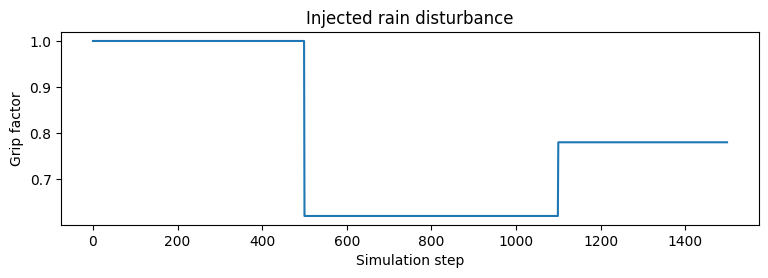

In [ ]:
# Cell 21 — rain disturbance
def environmental_grip(step):
    # Demonstration: dry -> rain transition -> partial recovery.
    if step < 500: return 1.00
    if step < 1100: return 0.62
    return 0.78

plt.figure(figsize=(9,2.5))
steps=np.arange(1500)
plt.plot(steps,[environmental_grip(i) for i in steps])
plt.xlabel("Simulation step"); plt.ylabel("Grip factor"); plt.title("Injected rain disturbance")
plt.show()


### Decoding Cell 21 (Rain Disturbance / Track Grip Profile) in Car Terms

If you understand track days, autocross, or wet-weather racing, **Cell 21** simulates a **sudden rainstorm rolling over the circuit during your session**:

*   **`environmental_grip(step)` (Changing Track Conditions):** This function simulates how much mechanical and chemical grip the tarmac offers over the course of a 1500-step run. It splits your track session into three distinct phases:
    1.  **Steps 0 to 499 (Dry Track):** The tarmac is bone dry and warm. Your racing slick tires have maximum traction, represented by a grip coefficient of `1.00`. You can brake late, carry high speed through corners, and get on the throttle early.
    2.  **Steps 500 to 1099 (Sudden Downpour):** At step 500, the heavens open up. Rain instantly drenches the track, dropping available road grip down to `0.62` (a 38% loss in traction). If you try to carry dry-weather speeds, you will hydroplane, push wide in corners, or spin out. The car's stability systems must immediately adapt to prevent a crash.
    3.  **Steps 1100 to 1499 (Drying Racing Line):** The rain stops, and cars driving on the track begin to clear water off the asphalt, creating a "drying line." Grip partially recovers to `0.78`. It's not fully dry yet, but there is noticeably more bite than during the peak of the storm, allowing the vehicle to pick up the pace again.
*   **The Grip Plot:** The line graph generated by this cell is your track's dynamic friction profile over time. It visually maps out exactly when you transition from driving on hot, dry asphalt to hitting a wet, slippery surface, and then managing the greasy, damp recovery phase.

### Cell 22 — Inject sensor degradation and uncertainty

This cell develops one layer of the simulator while preserving the separation of responsibilities that is essential to the control architecture. The purpose is not simply to add another Python function. It is to make explicit **what information this component is allowed to see, what transformation it performs, and what authority it possesses**. Those boundaries are important because autonomous systems fail when perception, reasoning, control, and execution are casually collapsed into a single opaque mechanism.

At this stage, pay attention to the direction of information flow. A component should consume a defined input and produce a defined output that can be inspected by the next component. Later, the live dashboard will expose these messages while the vehicle moves. This allows the class to distinguish a sensor observation from an estimated state, an estimated state from a judgment, a judgment from an authorized command, and an authorized command from the physical response of the vehicle.

The code deliberately favors clarity and inspectability over high-fidelity motorsport physics. We are building a pedagogical simulator, not a safety-certified autonomous-driving stack or a Formula 1 engineering model. Nevertheless, the conceptual separation mirrors real control-system ideas: noisy measurements, state representation, reference trajectories, feedback control, supervisory reasoning, constraints, actuator saturation, physical dynamics, and repeated feedback.

A second theme is **time scale**. Not every form of intelligence should operate at the same frequency. Geometry and deterministic feedback can be evaluated every simulation step. Strategic LLM reasoning is slower and should be invoked only at supervisory intervals or when an event warrants reconsideration. The simulator therefore rejects the tempting but unrealistic architecture in which a language model is asked to generate steering commands continuously.

As you run this cell, interpret its output as one message in a larger institutional architecture. The same conceptual structure can later be translated to finance: observations become data, state estimation becomes analytical interpretation, judgment becomes policy or recommendation, governance becomes limits and approvals, execution becomes transactions, and feedback becomes monitoring of realized consequences.

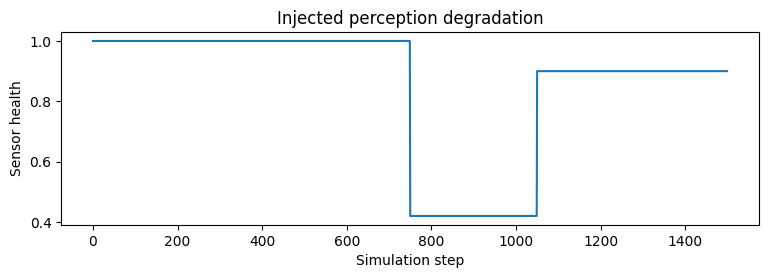

In [ ]:
# Cell 22 — sensor degradation
def sensor_health_schedule(step):
    if step < 750: return 1.0
    if step < 1050: return 0.42
    return 0.90

plt.figure(figsize=(9,2.5))
steps=np.arange(1500)
plt.plot(steps,[sensor_health_schedule(i) for i in steps])
plt.xlabel("Simulation step"); plt.ylabel("Sensor health"); plt.title("Injected perception degradation")
plt.show()


### Decoding Cell 22 (Sensor Degradation / Hardware Glitch Schedule) in Car Terms

If you understand track days and paddock diagnostics, **Cell 22** simulates **electrical gremlins, mud on your cameras, or loose sensor grounds developing mid-race**:

*   **`sensor_health_schedule(step)` (The Wiring Harness Fault Timeline):** This function simulates the physical reliability of your car's wiring and telemetry hardware over the course of the 1500-step run:
    1.  **Steps 0 to 749 (Perfect Sensor Ground):** Everything is clean and fully operational. Your sensors have a health rating of `1.0` (100%). Your speed sensors, GPS, and optical cameras are providing pristine, noise-free telemetry to the main computer.
    2.  **Steps 750 to 1049 (Mud on the Lens / Wiring Harness Vibration):** At step 750, the car experiences a hardware glitch. Perhaps you ran wide over a curb and kicked up mud that splattered across the optical cameras, or high-frequency vibration loosened a sensor ground wire. Your sensor health instantly plunges to `0.42` (42%). The telemetry feeds become extremely noisy and erratic, putting your car's electronic brain to the ultimate test.
    3.  **Steps 1050 to 1499 (Self-Cleaning / Pit Lane Quick-Fix):** At step 1050, the system recovers to `0.90` (90%). Think of this as the windshield wipers finally clearing the mud off the camera lens, or an automated redundant backup circuit taking over the loose ground wire. The data signals clean up, and the car's telemetry returns to near-perfect accuracy.
*   **The Sensor Health Plot:** This graph shows the timeline of your electrical system's reliability. By overlaying this timeline with the wet-weather track timeline from Cell 21, you are creating the ultimate automotive worst-case scenario: driving a high-horsepower racecar through a sudden rainstorm (low grip) while your traction control and dashboard sensors are acting up and sending garbage data (low sensor health).

### Cell 23 — Run competing control architectures

This cell develops one layer of the simulator while preserving the separation of responsibilities that is essential to the control architecture. The purpose is not simply to add another Python function. It is to make explicit **what information this component is allowed to see, what transformation it performs, and what authority it possesses**. Those boundaries are important because autonomous systems fail when perception, reasoning, control, and execution are casually collapsed into a single opaque mechanism.

At this stage, pay attention to the direction of information flow. A component should consume a defined input and produce a defined output that can be inspected by the next component. Later, the live dashboard will expose these messages while the vehicle moves. This allows the class to distinguish a sensor observation from an estimated state, an estimated state from a judgment, a judgment from an authorized command, and an authorized command from the physical response of the vehicle.

The code deliberately favors clarity and inspectability over high-fidelity motorsport physics. We are building a pedagogical simulator, not a safety-certified autonomous-driving stack or a Formula 1 engineering model. Nevertheless, the conceptual separation mirrors real control-system ideas: noisy measurements, state representation, reference trajectories, feedback control, supervisory reasoning, constraints, actuator saturation, physical dynamics, and repeated feedback.

A second theme is **time scale**. Not every form of intelligence should operate at the same frequency. Geometry and deterministic feedback can be evaluated every simulation step. Strategic LLM reasoning is slower and should be invoked only at supervisory intervals or when an event warrants reconsideration. The simulator therefore rejects the tempting but unrealistic architecture in which a language model is asked to generate steering commands continuously.

As you run this cell, interpret its output as one message in a larger institutional architecture. The same conceptual structure can later be translated to finance: observations become data, state estimation becomes analytical interpretation, judgment becomes policy or recommendation, governance becomes limits and approvals, execution becomes transactions, and feedback becomes monitoring of realized consequences.

In [ ]:
# Cell 23 — architecture runner
def run_architecture(steps=1400, use_llm=False, disturbances=True):
    st = VehicleState(track[0,0],track[0,1],heading[0],22.0)
    est = StateEstimator()
    policy = DEFAULT_POLICY.copy()
    log, packets = [], []
    for k in range(steps):
        st.grip = environmental_grip(k) if disturbances else 1.0
        health = sensor_health_schedule(k) if disturbances else 1.0

        if use_llm and (k % LLM_INTERVAL_STEPS == 0):
            summary = {
                "speed_mps":round(st.speed,2), "grip":round(st.grip,2),
                "sensor_health":round(health,2),
                "recent_mode":policy["mode"]
            }
            policy = validate_policy(claude_supervisor(summary))

        st, packet = control_cycle(st, est, policy, health)
        log.append(telemetry_row(st,packet)); packets.append(packet)

        # pedagogical reset if vehicle departs badly, keeping demo running
        idx=nearest_track_index(st.x,st.y)
        if np.linalg.norm(np.array([st.x,st.y])-track[idx]) > 45:
            st.x,st.y=track[idx]; st.yaw=heading[idx]; st.speed=min(st.speed,18)
    return log, packets

baseline_log, _ = run_architecture(500, use_llm=False, disturbances=False)
print("Baseline run complete:", len(baseline_log), "cycles")


Baseline run complete: 500 cycles


### Decoding Cell 23 (Architecture Runner / The Track Test Session) in Car Terms

If you understand track days, dyno pulls, or running telemetry comparisons back in the paddock, **Cell 23** is your **Test Session Coordinator**:

*   **`run_architecture(...)` (Setting Up a Test Session):** Think of this as sending your test car out of the pit lane onto the circuit for a series of hot laps under different conditions to compare configurations.
*   **The Test Variables:**
    *   **`steps=1400` (Session Length):** The number of sectors or micro-seconds to run before waving the checkered flag.
    *   **`use_llm=False/True` (Crew Chief Style):**
        *   When `False`, the car runs on static, pre-programmed settings (like a standard traction control system that has no dynamic track modes).
        *   When `True`, your "virtual pit lane crew chief" (the language model) is actively looking at telemetry and calling the driver over the team radio every few laps (`LLM_INTERVAL_STEPS`) to adjust the car's setup mapping.
    *   **`disturbances=True/False` (The Weather & Hardware Factor):** Determines whether we test on a perfect, sunny day with flawless hardware (`False`), or deliberately simulate a worst-case scenario (`True`) with sudden downpours (Cell 21) and vibrating sensor connections (Cell 22).
*   **`nearest_track_index` & The Reset Rule (The "Off-Track" Tow Truck):** During testing, if the car completely loses control and slides more than 45 meters off-course, the track marshals wave the red flag, retrieve the car from the gravel trap, reset it safely back on the driving line, drop its speed down to a safe $18\text{ m/s}$, and let the test continue so you can keep collecting data rather than instantly ending your track day in a barrier.
*   **`baseline_log` (The Control Lap):** This specific run runs a short 500-step test with zero rain and perfect sensors. This is your "qualifying run" or "baseline dry lap" that you use as a reference point to compare against when things get wet and chaotic later.

### Cell 24 — Render the live signal-flow simulator

This cell develops one layer of the simulator while preserving the separation of responsibilities that is essential to the control architecture. The purpose is not simply to add another Python function. It is to make explicit **what information this component is allowed to see, what transformation it performs, and what authority it possesses**. Those boundaries are important because autonomous systems fail when perception, reasoning, control, and execution are casually collapsed into a single opaque mechanism.

At this stage, pay attention to the direction of information flow. A component should consume a defined input and produce a defined output that can be inspected by the next component. Later, the live dashboard will expose these messages while the vehicle moves. This allows the class to distinguish a sensor observation from an estimated state, an estimated state from a judgment, a judgment from an authorized command, and an authorized command from the physical response of the vehicle.

The code deliberately favors clarity and inspectability over high-fidelity motorsport physics. We are building a pedagogical simulator, not a safety-certified autonomous-driving stack or a Formula 1 engineering model. Nevertheless, the conceptual separation mirrors real control-system ideas: noisy measurements, state representation, reference trajectories, feedback control, supervisory reasoning, constraints, actuator saturation, physical dynamics, and repeated feedback.

A second theme is **time scale**. Not every form of intelligence should operate at the same frequency. Geometry and deterministic feedback can be evaluated every simulation step. Strategic LLM reasoning is slower and should be invoked only at supervisory intervals or when an event warrants reconsideration. The simulator therefore rejects the tempting but unrealistic architecture in which a language model is asked to generate steering commands continuously.

As you run this cell, interpret its output as one message in a larger institutional architecture. The same conceptual structure can later be translated to finance: observations become data, state estimation becomes analytical interpretation, judgment becomes policy or recommendation, governance becomes limits and approvals, execution becomes transactions, and feedback becomes monitoring of realized consequences.

In [ ]:
# Cell 24 — live signal-flow visualization
def render_simulator(log, packets, every=8, max_frames=160):
    ids = np.linspace(0, len(log)-1, min(max_frames, max(2,len(log)//every))).astype(int)
    fig = plt.figure(figsize=(13,7))
    ax = fig.add_axes([0.05,0.10,0.55,0.82])
    panel = fig.add_axes([0.64,0.10,0.33,0.82]); panel.axis("off")
    ax.plot(track[:,0],track[:,1],lw=2)
    car_dot, = ax.plot([],[],'o',ms=8)
    trail, = ax.plot([],[],lw=1)
    ax.axis("equal"); ax.set_title("Vehicle / environment")
    text = panel.text(0,1,"",va="top",family="monospace",fontsize=10)

    def frame(j):
        i=ids[j]; row=log[i]; p=packets[i]
        lo=max(0,i-80)
        trail.set_data([r["x"] for r in log[lo:i+1]],[r["y"] for r in log[lo:i+1]])
        car_dot.set_data([row["x"]],[row["y"]])
        flow = (
          "LIVE CONTROL ARCHITECTURE\n"
          "=========================\n\n"
          "ENVIRONMENT\n"
          f" grip={row['grip']:.2f}\n"
          "       ↓\nPERCEPTION\n"
          f" confidence={row['confidence']:.2f}\n"
          "       ↓\nSTATE ESTIMATION\n"
          f" speed={row['speed']*3.6:5.1f} km/h\n"
          "       ↓\nJUDGMENT / SUPERVISION\n"
          f" mode={row['mode']}\n"
          f" target={row['target_speed']*3.6:5.1f} km/h\n"
          "       ↓\nSAFETY GOVERNOR\n"
          f" verdict={row['governor']}\n"
          "       ↓\nEXECUTION\n"
          f" throttle={row['throttle']:.2f}\n"
          f" brake={row['brake']:.2f}\n"
          f" steer={np.rad2deg(row['steer']):+.1f}°\n"
          "       ↓\nVEHICLE → FEEDBACK"
        )
        text.set_text(flow)
        return car_dot,trail,text

    ani=FuncAnimation(fig,frame,frames=len(ids),interval=90,blit=False)
    plt.close(fig)
    return HTML(ani.to_jshtml())

print("Renderer ready. Cell 25 will run the integrated classroom demonstration.")


Renderer ready. Cell 25 will run the integrated classroom demonstration.


### Decoding Cell 24 (Live Signal-Flow Visualization / The Pit Wall Telemetry Screen) in Car Terms

If you have ever looked at a racecar's digital steering wheel display or watched a Formula 1 team's live pit-wall telemetry screen during a race, **Cell 24** is the code that **builds and renders that live dashboard**:

*   **`render_simulator(...)` (The Pit Wall Telemetry Screen):** This function generates a live-updating split-screen dashboard. On the left side, it draws a GPS track map showing your car's actual position (the blue dot) and its recent racing line (the trail). On the right side, it formats a live text readout of the car's vitals—exactly like the telemetry screens engineers analyze in the garage to monitor a car's performance.
*   **The Live Signal Flow (The Car's Nervous System):**
    *   **ENVIRONMENT (`grip`):** This is the actual track condition. Think of it as a live sensor measuring the physical wetness or temperature of the tarmac right under the tires.
    *   **PERCEPTION (`confidence`):** This is the dashboard's warning indicator for your camera and sensor lens cleanliness. If mud splatters on the lens or a wire gets loose, your sensor confidence drops (just like a warning light on your dash).
    *   **STATE ESTIMATION (`speed`):** Your digital speedometer, displaying your actual vehicle speed calculated in km/h (derived from wheelspeed sensors and GPS).
    *   **JUDGMENT / SUPERVISION (`mode` & `target`):** This is the active ECU Map (e.g., "Dry Mode" or "Rain Mode") and your target speed. It is what your "virtual Crew Chief" has instructed the car's computer to aim for based on the weather conditions.
    *   **SAFETY GOVERNOR (`verdict`):** This is your active Traction Control (TC), Electronic Stability Control (ESC), or ABS override indicator. It shows whether the system is letting your inputs pass straight through to the wheels (`"ACCEPT"`) or if the safety computer is stepping in to cut power or pump the brakes to keep you from spinning out (`"OVERRIDE"`).
    *   **EXECUTION (`throttle`, `brake`, `steer`):** The physical pedal and steering wheel positions. This is your telemetry trace showing exactly how much throttle (0-100%), braking pressure, and steering angle (in degrees) is being applied to the tires at this split second.
*   **The Animation (`FuncAnimation`):** This plays back your entire track session like a telemetry replay, allowing you to watch exactly how the car's electronic brain and safety systems reacted the moment the storm hit and your sensors glitched.

### Cell 25 — Run the classroom experiment and summarize results

This cell develops one layer of the simulator while preserving the separation of responsibilities that is essential to the control architecture. The purpose is not simply to add another Python function. It is to make explicit **what information this component is allowed to see, what transformation it performs, and what authority it possesses**. Those boundaries are important because autonomous systems fail when perception, reasoning, control, and execution are casually collapsed into a single opaque mechanism.

At this stage, pay attention to the direction of information flow. A component should consume a defined input and produce a defined output that can be inspected by the next component. Later, the live dashboard will expose these messages while the vehicle moves. This allows the class to distinguish a sensor observation from an estimated state, an estimated state from a judgment, a judgment from an authorized command, and an authorized command from the physical response of the vehicle.

The code deliberately favors clarity and inspectability over high-fidelity motorsport physics. We are building a pedagogical simulator, not a safety-certified autonomous-driving stack or a Formula 1 engineering model. Nevertheless, the conceptual separation mirrors real control-system ideas: noisy measurements, state representation, reference trajectories, feedback control, supervisory reasoning, constraints, actuator saturation, physical dynamics, and repeated feedback.

A second theme is **time scale**. Not every form of intelligence should operate at the same frequency. Geometry and deterministic feedback can be evaluated every simulation step. Strategic LLM reasoning is slower and should be invoked only at supervisory intervals or when an event warrants reconsideration. The simulator therefore rejects the tempting but unrealistic architecture in which a language model is asked to generate steering commands continuously.

As you run this cell, interpret its output as one message in a larger institutional architecture. The same conceptual structure can later be translated to finance: observations become data, state estimation becomes analytical interpretation, judgment becomes policy or recommendation, governance becomes limits and approvals, execution becomes transactions, and feedback becomes monitoring of realized consequences.

In [ ]:
# Cell 25 — integrated classroom experiment
# Set USE_CLAUDE=True to activate the slower strategic supervisory layer.
# The notebook remains runnable without an API connection through deterministic fallback.
USE_CLAUDE = True

demo_log, demo_packets = run_architecture(
    steps=1400, use_llm=USE_CLAUDE, disturbances=True
)

display(render_simulator(demo_log, demo_packets))

# Compact quantitative summary
speeds = np.array([r["speed"] for r in demo_log])*3.6
mods = sum(r["governor"] != "ACCEPT" for r in demo_log)
low_conf = sum(r["confidence"] < 0.60 for r in demo_log)

print("\nCLASSROOM SUMMARY")
print("-----------------")
print(f"Mean speed: {speeds.mean():.1f} km/h")
print(f"Maximum speed: {speeds.max():.1f} km/h")
print(f"Governor interventions: {mods}")
print(f"Low-confidence cycles: {low_conf}")
print(f"Claude supervisory layer requested: {USE_CLAUDE}")
print("\nInterpretation: the moving vehicle is the consequence of the architecture;")
print("the LLM is only one bounded component inside that architecture.")



CLASSROOM SUMMARY
-----------------
Mean speed: 72.1 km/h
Maximum speed: 146.3 km/h
Governor interventions: 321
Low-confidence cycles: 300
Claude supervisory layer requested: True

Interpretation: the moving vehicle is the consequence of the architecture;
the LLM is only one bounded component inside that architecture.


### Decoding Cell 25 (Integrated Experiment & Summary) in Car Terms

If you understand paddock diagnostics, tuning, or reading post-session telemetry reports, **Cell 25** is your **Full-Scale Wet-Weather Race Track Test and Post-Race Summary Sheet**:

*   **`USE_CLAUDE = True` (Activating the Crew Chief):** By turning this on, you place your highly intelligent "virtual Crew Chief" on the pit wall. Instead of letting the driver struggle blindly on a static dry setup when it starts pouring, the Crew Chief dynamically adjusts the ECU maps and driving strategy via the team radio as track conditions mutate.
*   **`run_architecture(...)` (The 1400-Sector Enduro Test):** This fires up the engine and sends the car out for a grueling 1400-sector test run. It subjects the vehicle to the exact storm profile (wet asphalt) and electrical gremlins (vibrating sensor wires) you set up earlier, logging every millisecond of the chassis' behavior.
*   **`display(render_simulator(...))` (The Telemetry Replay VCR):** This compiles all your logged telemetry into a synchronized video playback. You can watch the car negotiate the curves, see the driver's throttle and steering inputs, and watch the exact moment the stability control overrides the driver as the tires lose traction on the wet track.
*   **The Post-Race Summary Sheet (Paddock Diagnostics):**
    *   **Mean Speed (Average Lap Pace):** How fast, on average, the car was able to lap the circuit. A higher average speed means your strategic adaptations worked efficiently.
    *   **Maximum Speed (Top Speed Trap):** The fastest velocity the car achieved down the straightaway.
    *   **Governor Interventions (Traction Control / ABS Counter):** The exact number of times the physical safety systems had to step in and save the car from a crash. If this number is extremely high, it means the car was being driven too aggressively for the conditions, forcing the safety net to constantly bail it out.
    *   **Low-Confidence Cycles (Sensor Blackouts):** The total amount of time the car's sensors were "blinded" or malfunctioning due to electrical noise. This shows how long the vehicle had to drive "by feel" without reliable telemetry.
*   **The Central Lesson:** The car moving around the track is simply the physical symptom of the underlying architecture. The AI (the Crew Chief) is not physically steering the car; it is merely one component of a larger, highly governed system of sensors, estimators, mechanical limits, and safety overrides working in harmony.

# Conclusion — What the Simulator Teaches

The vehicle that moved around the circuit was the visible outcome of a much less visible process. That distinction is the central lesson of this notebook. When observers say that an autonomous vehicle “sees,” “decides,” or “drives,” ordinary language compresses a collection of heterogeneous mechanisms into a single apparent intelligence. The simulator has deliberately decompressed that process.

The first conclusion is that **perception is not judgment**. Sensors generated measurements of speed, orientation, track geometry, and environmental conditions. Those measurements could contain noise and could become unreliable. The architecture therefore attached confidence to perception rather than treating every observation as truth. This is an important general principle: an autonomous system should know not only what it observes but something about the quality of the observation.

Second, **observation is not state**. The state estimator converted measurements into a more stable internal representation. The vehicle acted on an estimate of reality, not reality itself. This is true far beyond autonomous driving. Financial institutions, central banks, corporations, and human decision makers all operate on representations of states that cannot be observed perfectly.

Third, **judgment operates at different time scales**. The fast controller handled continuous steering and speed regulation. Claude Haiku 4.5 occupied a deliberately slower supervisory role. This division prevents a language model from being assigned a task for which latency, stochasticity, and linguistic reasoning are inappropriate. The LLM can interpret a deteriorating environment, choose a strategic mode, or recommend a more conservative policy. It does not need to decide the steering angle every tenth of a second.

Fourth, **intelligence does not imply authority**. The safety governor stood between recommendation and execution. Its job was not to be more intelligent than the reasoning layer. Its job was to enforce constraints. If confidence deteriorated, grip fell, the vehicle approached a physical envelope, or a strategic recommendation became too aggressive, deterministic rules could modify the proposed action. This separation is crucial in any high-consequence autonomous architecture.

Fifth, **execution is a separate problem**. Even an authorized command does not directly determine the next state. The command encounters a physical system: inertia, steering limits, braking capability, available grip, and disturbances. The resulting state is therefore an empirical consequence of an action rather than a synonym for the action itself.

Sixth, **feedback makes autonomy dynamic**. The result of execution became the environment for the next observation. The architecture did not produce one answer. It produced a recurrent sequence:

**observe → estimate → judge → govern → execute → observe again.**

This recurrent structure explains why autonomous systems are better understood as control architectures than as isolated models.

The rain and sensor-degradation experiments expose another important property: different disturbances challenge different layers. Rain primarily changes the physical relationship between requested action and achievable motion. Sensor degradation attacks the quality of information entering the architecture. An intelligent system should respond differently to these two problems. A reduction in grip calls for a changed physical operating envelope. A reduction in sensor confidence calls for epistemic caution: the system should act differently because it knows less.

Claude's role also illustrates the broader course argument about the evolution of artificial intelligence. Generative AI did not make geometry, statistical estimation, control theory, optimization, or deterministic software obsolete. Instead, it added another form of intelligence to an already heterogeneous stack. The resulting architecture can become richer precisely because different methods specialize in different problems.

This observation provides a direct bridge to autonomous financial institutions. Replace cameras and sensors with market, accounting, regulatory, and client data. Replace state estimation with analytical models. Replace driving strategy with portfolio, credit, treasury, or management judgment. Replace the vehicle safety governor with risk limits, compliance rules, delegated authorities, and human approvals. Replace actuators with trading systems, payment rails, workflow engines, and contractual execution. The structural problem remains remarkably similar.

The final proposition can therefore be stated compactly:

**Autonomous intelligence is not a model. It is a governed feedback architecture.**

A language model may be a powerful reasoning component within that architecture. It may interpret context, synthesize information, generate hypotheses, select strategies, or coordinate specialized agents. But perception must still establish what appears to be happening; models must transform observations into useful states; control mechanisms must translate objectives into actions; governance must determine which actions are permissible; execution mechanisms must interact with the world; and feedback must reveal the consequences.

The moving car is therefore almost incidental. What matters is the machinery underneath it. Once students can see that machinery operating in real time, the concept of autonomous systems becomes much more concrete—and much easier to transfer from a self-driving car to the autonomous financial institution.